# FreshRetailNet-50K — Stockout-aware demand forecasting, Phases 0–4

**Forecast task.** At the end of day *t−1*, forecast the demand for day *t* in the 06:00–21:00 window (hourly slots 6–21, 16 hours). The forecast will later be used for ordering.

**Scope of this notebook.** Phases 0–4 only:

| Phase | Content |
|---|---|
| 0 | Reproducible workspace: configuration, provenance, split manifest, series sampling, pipeline library, 10-series smoke check |
| 1 | Data audit, donor availability, past-only features, leakage checks |
| 2 | Three demand-dependent stockout simulators (A/B/C) that produce three *different historical timelines* |
| 3 | Conventional baselines per timeline: seasonal naive, raw-sales LightGBM, raw-sales LightGBM quantiles |
| 4 | Main demand quantile LightGBM models (τ ∈ {0.25, 0.50, 0.75, 0.90}) × A/B/C = 12 models trained on donor proxy labels |

**Not done here (later phases):** conformal calibration, Kaplan–Meier ordering, TimesNet/TFT, inventory-cost optimisation, final A/B/C transfer evaluation, final paper claims. The reserved calibration dates (days 76–90) are used only to count donor availability, and the final evaluation week is only checked for schema and row counts.

**Key assumption.** A day with no flagged stockout in 06:00–21:00 is a *complete donor day*. Its recorded 16-hour sales are used as a **proxy** for full demand. That is still an assumption: donors are a selected subset, and the sales are normalised. A genuinely stocked-out day's recorded total is never treated as an exact demand label.

Every gate below is computed by code. A gate only reads PASS when its assertions ran and held in this execution.

## Configuration (edit here)

Every setting can also be overridden with an environment variable (`FRN_*`). That is how the full-data run is executed from the same notebook without editing its logic.

In [1]:
import os
from pathlib import Path

# ---------------- EDITABLE CONFIGURATION ----------------
DATA_DIR = os.environ.get("FRN_DATA_DIR", "")          # folder holding train.parquet + eval.parquet; "" = auto-search
OUTPUT_DIR = os.environ.get("FRN_OUTPUT_DIR", "frn_outputs")  # created next to the notebook if relative
SEED = int(os.environ.get("FRN_SEED", "20240628"))
FAST_MODE = os.environ.get("FRN_FAST_MODE", "0") == "1"   # True -> smaller LightGBM grids and fewer boosting rounds
SAMPLE_N_SERIES = int(os.environ.get("FRN_SAMPLE_N", "5000"))
SMOKE_N_SERIES = 10
FULL_RUN = os.environ.get("FRN_FULL_RUN", "0") == "1"      # True -> all 50,000 series, same research logic
N_THREADS = int(os.environ.get("FRN_THREADS", str(os.cpu_count() or 2)))
# ---------------------------------------------------------

RUN_TAG = "full50k" if FULL_RUN else f"demo{SAMPLE_N_SERIES}"
print(f"RUN_TAG={RUN_TAG}  FULL_RUN={FULL_RUN}  FAST_MODE={FAST_MODE}  SEED={SEED}  threads={N_THREADS}")

RUN_TAG=demo5000  FULL_RUN=False  FAST_MODE=False  SEED=20240628  threads=2


In [2]:
os.environ.setdefault("ARROW_DEFAULT_MEMORY_POOL", "system")   # return freed Arrow memory to the OS
import sys, json, time, hashlib, platform, datetime as dtm, threading, gc, warnings, importlib, subprocess
import numpy as np
import pandas as pd

def _ensure(pkg, pip_name=None):
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return importlib.import_module(pkg)

pa = _ensure("pyarrow"); import pyarrow.parquet as pq, pyarrow.compute as pc
lgb = _ensure("lightgbm")
psutil = _ensure("psutil")
duckdb = _ensure("duckdb")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 250); pd.set_option("display.max_colwidth", 90)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# ---- locate data without machine-specific paths ----
def locate_data(explicit=""):
    cands = [Path(explicit)] if explicit else []
    here = Path.cwd()
    cands += [here, here / "data", here.parent, here.parent / "data", Path.home() / "Downloads",
              Path.home() / "data" / "FreshRetailNet-50K", Path("/mnt/user-data/uploads"), Path("/mnt/user-data/uploads/Downloads")]
    for c in cands:
        if (c / "train.parquet").exists() and (c / "eval.parquet").exists():
            return c.resolve()
        if (c / "data" / "train.parquet").exists() and (c / "data" / "eval.parquet").exists():
            return (c / "data").resolve()
    raise FileNotFoundError("train.parquet/eval.parquet not found. Set DATA_DIR or FRN_DATA_DIR. Searched: " + ", ".join(map(str, cands)))

DATA = locate_data(DATA_DIR)
TRAIN_PATH, EVAL_PATH = DATA / "train.parquet", DATA / "eval.parquet"
OUT = Path(OUTPUT_DIR)
if not OUT.is_absolute():
    OUT = Path.cwd() / OUT
OUT = OUT / RUN_TAG
SUBDIRS = ["manifests", "data", "sim", "models", "predictions", "metrics", "figures"]
for s in SUBDIRS:
    (OUT / s).mkdir(parents=True, exist_ok=True)
print("data folder  :", DATA)
print("output folder:", OUT)

data folder  : /mnt/user-data/uploads/Downloads
output folder: /home/claude/frn/frn_outputs/demo5000


### Stage timer (runtime and peak memory)
Each major stage runs inside `stage(name)`. A background thread samples the process RSS every 0.1 s, so the table records wall time and the stage's peak resident memory.

In [ ]:
STAGES = []
class stage:
    def __init__(self, name): self.name = name
    def __enter__(self):
        self.p = psutil.Process(); self.peak = self.p.memory_info().rss; self.stop = False
        def poll():
            while not self.stop:
                self.peak = max(self.peak, self.p.memory_info().rss); time.sleep(0.1)
        self.th = threading.Thread(target=poll, daemon=True); self.th.start(); self.t0 = time.time(); return self
    def __exit__(self, *exc):
        self.stop = True; self.th.join()
        self.peak = max(self.peak, self.p.memory_info().rss)
        STAGES.append({"stage": self.name, "seconds": round(time.time() - self.t0, 2),
                       "peak_rss_GB": round(self.peak / 1e9, 3), "ok": exc[0] is None})
        print(f"[stage] {self.name}: {time.time()-self.t0:.1f}s, peak RSS {self.peak/1e9:.2f} GB")
        return False

GATES = {}   # phase -> list of (check, bool, detail)
def gate(phase, name, ok, detail=""):
    ok = bool(ok)
    GATES.setdefault(phase, []).append({"phase": phase, "check": name, "status": "PASS" if ok else "FAIL", "detail": str(detail)})
    print(f"  [{'PASS' if ok else 'FAIL'}] {phase} | {name} {('— ' + str(detail)) if detail else ''}")
    return ok

def gate_summary(phase):
    df = pd.DataFrame(GATES.get(phase, []))
    status = "PASS" if len(df) and (df.status == "PASS").all() else "FAIL"
    display(df)
    print(f"==== {phase} EXIT GATE: {status} ({(df.status=='PASS').sum()}/{len(df)} checks passed) ====")
    return status
def free_mem():
    """Garbage-collect and, on glibc (Linux), hand freed heap pages back to the OS so peak memory stays bounded."""
    gc.collect()
    try:
        import ctypes
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass
RUN_T0 = time.time()

# Phase 0 — Reproducible workspace

**Plain language.** This phase makes sure anyone can rerun the notebook and get the same result. It records where the data came from (file hashes), which software and machine ran it, and how the 90 training days are split. It then picks the 5,000 demonstration series with a rule that only looks at the first 60 days. Finally it defines every pipeline function once and runs them end to end on 10 series before scaling up.

In [4]:
def sha256_file(p, chunk=1 << 22):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

with stage("P0 provenance + hashes"):
    pkgs = {}
    for m in ["numpy", "pandas", "pyarrow", "lightgbm", "matplotlib", "scipy", "duckdb", "psutil", "ipykernel", "nbclient"]:
        try:
            pkgs[m] = importlib.import_module(m).__version__
        except Exception as e:
            pkgs[m] = f"unavailable ({type(e).__name__})"
    vm = psutil.virtual_memory()
    provenance = {
        "run_started_utc": dtm.datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "config": {"RUN_TAG": RUN_TAG, "SEED": SEED, "FAST_MODE": FAST_MODE, "SAMPLE_N_SERIES": SAMPLE_N_SERIES,
                    "SMOKE_N_SERIES": SMOKE_N_SERIES, "FULL_RUN": FULL_RUN, "N_THREADS": N_THREADS},
        "python": sys.version.split()[0], "packages": pkgs,
        "machine": {"platform": platform.platform(), "processor": platform.processor() or platform.machine(),
                     "logical_cpus": os.cpu_count(), "ram_GB": round(vm.total / 1e9, 2)},
        "source_files": {p.name: {"sha256": sha256_file(p), "bytes": p.stat().st_size} for p in [TRAIN_PATH, EVAL_PATH]},
    }
json.dump(provenance, open(OUT / "manifests" / "provenance.json", "w"), indent=2)
print(json.dumps(provenance, indent=2))

[stage] P0 provenance + hashes: 0.3s, peak RSS 0.28 GB
{
  "run_started_utc": "2026-09-20T16:29:24Z",
  "config": {
    "RUN_TAG": "demo5000",
    "SEED": 20240628,
    "FAST_MODE": false,
    "SAMPLE_N_SERIES": 5000,
    "SMOKE_N_SERIES": 10,
    "FULL_RUN": false,
    "N_THREADS": 2
  },
  "python": "3.11.15",
  "packages": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "pyarrow": "25.0.1",
    "lightgbm": "4.7.0",
    "matplotlib": "3.10.9",
    "scipy": "1.17.1",
    "duckdb": "1.5.5",
    "psutil": "7.2.2",
    "ipykernel": "7.3.0",
    "nbclient": "0.11.0"
  },
  "machine": {
    "platform": "Linux-6.18.44-fc-v37-x86_64-with-glibc2.39",
    "processor": "x86_64",
    "logical_cpus": 2,
    "ram_GB": 8.42
  },
  "source_files": {
    "train.parquet": {
      "sha256": "6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d",
      "bytes": 106436287
    },
    "eval.parquet": {
      "sha256": "1b118840664280c6b88bffc84c80ee1f54c05d911e354b7599e5da10995e960e",
      

### Split manifest
Day numbers are 1-based positions in the 90-day train split; `d` in code is 0-based (`d = day − 1`).

In [5]:
START = np.datetime64("2024-03-28")
N_DAYS = 90
DATES = START + np.arange(N_DAYS)
SPLITS = [
    ("model_fit",   1, 60, "Train model weights and fit initial simulator rules."),
    ("tuning",     61, 75, "Select hyperparameters and check simulator realism."),
    ("calibration", 76, 90, "Reserved: no fitting/tuning in Phases 0-4; donor counts for a feasibility audit only."),
]
split_rows = [{"use": u, "first_day": a, "last_day": b, "first_date": str(DATES[a-1]), "last_date": str(DATES[b-1]),
               "n_days": b - a + 1, "rule": r} for u, a, b, r in SPLITS]
split_rows.append({"use": "final_evaluation", "first_day": 91, "last_day": 97, "first_date": "2024-06-26", "last_date": "2024-07-02",
                   "n_days": 7, "rule": "eval split: schema and row counts only; outcomes are not read in this notebook."})
SPLIT_MANIFEST = pd.DataFrame(split_rows)
SPLIT_OF_DAY = np.empty(N_DAYS, dtype=object)
for u, a, b, _ in SPLITS:
    SPLIT_OF_DAY[a-1:b] = u
FIT_D = np.arange(0, 60); TUNE_D = np.arange(60, 75); CAL_D = np.arange(75, 90)
assert str(DATES[59]) == "2024-05-26" and str(DATES[60]) == "2024-05-27" and str(DATES[74]) == "2024-06-10" and str(DATES[75]) == "2024-06-11" and str(DATES[89]) == "2024-06-25"
SPLIT_MANIFEST.to_csv(OUT / "manifests" / "split_manifest.csv", index=False)
display(SPLIT_MANIFEST)

,use,first_day,last_day,first_date,last_date,n_days,rule
0,model_fit,1,60,2024-03-28,2024-05-26,60,Train model weights and fit initial simulator rules.
1,tuning,61,75,2024-05-27,2024-06-10,15,Select hyperparameters and check simulator realism.
2,calibration,76,90,2024-06-11,2024-06-25,15,Reserved: no fitting/tuning in Phases 0-4; donor counts for a feasibility audit only.
3,final_evaluation,91,97,2024-06-26,2024-07-02,7,eval split: schema and row counts only; outcomes are not read in this notebook.


### Dataset contract: schema, row counts, array lengths
Only metadata and identity/date columns of the **eval** split are read. Its outcome columns (`sale_amount`, `hours_sale`, stock fields) are never loaded.

In [6]:
with stage("P0 schema inspection"):
    EXPECTED = ["city_id", "store_id", "management_group_id", "first_category_id", "second_category_id", "third_category_id",
                "product_id", "dt", "sale_amount", "hours_sale", "stock_hour6_22_cnt", "hours_stock_status", "discount",
                "holiday_flag", "activity_flag", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level"]
    pf_tr, pf_ev = pq.ParquetFile(TRAIN_PATH), pq.ParquetFile(EVAL_PATH)
    schema_tbl = pd.DataFrame({"column": pf_tr.schema_arrow.names, "train_type": [str(t) for t in pf_tr.schema_arrow.types],
                               "eval_type": [str(pf_ev.schema_arrow.field(n).type) for n in pf_tr.schema_arrow.names]})
    display(schema_tbl)
    ev_ids = pq.read_table(EVAL_PATH, columns=["city_id", "store_id", "product_id", "dt"]).to_pandas()
    eval_info = {"rows": pf_ev.metadata.num_rows, "dates": sorted(ev_ids.dt.unique().tolist()),
                 "rows_per_date": ev_ids.dt.value_counts().sort_index().tolist(),
                 "n_series": int(ev_ids[["city_id", "store_id", "product_id"]].drop_duplicates().shape[0])}
    del ev_ids
print("train rows:", pf_tr.metadata.num_rows, "| eval rows:", eval_info["rows"])
print("eval dates:", eval_info["dates"], "\nrows per eval date:", eval_info["rows_per_date"], "| eval series:", eval_info["n_series"])
gate("Phase 0", "schema has all expected fields (train & eval)", set(EXPECTED) <= set(pf_tr.schema_arrow.names) and set(EXPECTED) <= set(pf_ev.schema_arrow.names))
gate("Phase 0", "train rows == 4,500,000", pf_tr.metadata.num_rows == 4_500_000, pf_tr.metadata.num_rows)
gate("Phase 0", "eval rows == 350,000", eval_info["rows"] == 350_000, eval_info["rows"])
gate("Phase 0", "eval dates are 2024-06-26..2024-07-02", eval_info["dates"] == [str(START + 90 + i) for i in range(7)])
json.dump(eval_info | {"note": "only identity/date columns were read"}, open(OUT / "manifests" / "eval_split_inspection.json", "w"), indent=2, default=str)

,column,train_type,eval_type
0,city_id,int64,int64
1,store_id,int64,int64
2,management_group_id,int64,int64
3,first_category_id,int64,int64
4,second_category_id,int64,int64
5,third_category_id,int64,int64
6,product_id,int64,int64
7,dt,string,string
8,sale_amount,double,double
9,hours_sale,list<element: double>,list<element: double>


[stage] P0 schema inspection: 0.3s, peak RSS 0.42 GB
train rows: 4500000 | eval rows: 350000
eval dates: ['2024-06-26', '2024-06-27', '2024-06-28', '2024-06-29', '2024-06-30', '2024-07-01', '2024-07-02'] 
rows per eval date: [50000, 50000, 50000, 50000, 50000, 50000, 50000] | eval series: 50000
  [PASS] Phase 0 | schema has all expected fields (train & eval) 
  [PASS] Phase 0 | train rows == 4,500,000 — 4500000
  [PASS] Phase 0 | eval rows == 350,000 — 350000
  [PASS] Phase 0 | eval dates are 2024-06-26..2024-07-02 


### Full-file streaming pass: global integrity audit and fit-period series statistics
The whole train file is read in record batches of 250k rows, never as a single table. The pass does two jobs:

1. **Global audit** of all 4.5M rows: nulls, hourly array lengths, negative sales, reconciliation of `sum(hours_sale)` with `sale_amount`, the identity `stock_hour6_22_cnt == sum(hours_stock_status[6:22])`, and duplicate or missing (series, date) keys.
2. **Per-series statistics** used for stratified sampling. Sampling statistics use **fit dates only** (days 1–60). Donor counts are also tallied per split, because counting donor availability is allowed for the feasibility audit.

The series key is `(city_id, store_id, product_id)`. It is packed into one integer as `city·10⁶ + store·10³ + product`, after asserting that store and product IDs are below 1000.

In [7]:
KEY_COLS = ["city_id", "store_id", "product_id"]
STATIC_COLS = ["management_group_id", "first_category_id", "second_category_id", "third_category_id"]
CTX_COLS = ["discount", "holiday_flag", "activity_flag", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level"]
H16 = slice(6, 22)            # 06:00-21:59 -> hourly slots 6..21
RECON_TOL = 1e-5              # |sum(hours_sale) - sale_amount| tolerance (float64 sums of float values)

def pack_key(city, store, product):
    return city.astype(np.int64) * 1_000_000 + store.astype(np.int64) * 1_000 + product.astype(np.int64)

def day_index(dt_arr):
    return (dt_arr.astype("datetime64[D]") - START).astype(np.int64)

def iter_train(columns, batch_size=250_000):
    for b in pq.ParquetFile(TRAIN_PATH).iter_batches(batch_size=batch_size, columns=columns):
        yield b

def batch_hourly(b, name, dtype):
    col = b.column(name)
    lens = pc.list_value_length(col).to_numpy(zero_copy_only=False)
    arr = col.values.to_numpy(zero_copy_only=False)
    ok = (lens == 24).all()
    return (arr.reshape(-1, 24).astype(dtype) if ok else None), lens

with stage("P0 global streaming audit"):
    kt = pq.read_table(TRAIN_PATH, columns=KEY_COLS + STATIC_COLS).to_pandas()
    assert kt.store_id.max() < 1000 and kt.product_id.max() < 1000 and kt.city_id.max() < 1000
    kt["key"] = pack_key(kt.city_id.values, kt.store_id.values, kt.product_id.values)
    SERIES_ALL = kt.drop_duplicates("key").sort_values("key").reset_index(drop=True)
    static_consistent = kt.groupby("key")[STATIC_COLS].nunique().max().max() == 1
    del kt
    ALL_KEYS = SERIES_ALL.key.values
    NS_ALL = len(ALL_KEYS)
    occ = np.zeros((NS_ALL, N_DAYS), np.int16)
    fit_y = np.zeros(NS_ALL); fit_so = np.zeros(NS_ALL); fit_n = np.zeros(NS_ALL)
    don = {u: np.zeros(NS_ALL, np.int32) for u in ["model_fit", "tuning", "calibration"]}
    A = dict(rows=0, nulls={}, bad_len_sale=0, bad_len_stock=0, neg_hourly=0, neg_sale_amount=0, recon_maxdiff=0.0,
             identity_mismatch=0, out_of_range_dates=0, stock_values=set(), flagged_hours=0, flagged_hours_with_sales=0,
             full_outage_days=0, full_outage_days_with_sales=0, max_hourly=0.0)
    cols = KEY_COLS + ["dt", "sale_amount", "hours_sale", "stock_hour6_22_cnt", "hours_stock_status"]
    for b in iter_train(cols):
        n = b.num_rows; A["rows"] += n
        for c in b.schema.names:
            A["nulls"][c] = A["nulls"].get(c, 0) + b.column(c).null_count
        Hb, lh = batch_hourly(b, "hours_sale", np.float64); Sb, ls = batch_hourly(b, "hours_stock_status", np.int8)
        A["bad_len_sale"] += int((lh != 24).sum()); A["bad_len_stock"] += int((ls != 24).sum())
        sa = b.column("sale_amount").to_numpy(); cnt = b.column("stock_hour6_22_cnt").to_numpy()
        A["neg_hourly"] += int((Hb < 0).sum()); A["neg_sale_amount"] += int((sa < 0).sum())
        A["max_hourly"] = max(A["max_hourly"], float(Hb.max()))
        A["recon_maxdiff"] = max(A["recon_maxdiff"], float(np.abs(Hb.sum(1) - sa).max()))
        s16 = Sb[:, H16].sum(1)
        A["identity_mismatch"] += int((s16 != cnt).sum())
        A["stock_values"] |= set(np.unique(Sb).tolist())
        A["flagged_hours"] += int(Sb[:, H16].sum()); A["flagged_hours_with_sales"] += int(((Sb[:, H16] == 1) & (Hb[:, H16] > 0)).sum())
        full = s16 == 16; A["full_outage_days"] += int(full.sum()); A["full_outage_days_with_sales"] += int((Hb[full][:, H16].sum(1) > 0).sum())
        d = day_index(np.array(b.column("dt").to_pylist(), dtype="datetime64[D]"))
        A["out_of_range_dates"] += int(((d < 0) | (d >= N_DAYS)).sum())
        key = pack_key(*(b.column(c).to_numpy() for c in KEY_COLS)); sid = np.searchsorted(ALL_KEYS, key)
        np.add.at(occ, (sid, d), 1)
        y16 = Hb[:, H16].sum(1); isfit = d < 60
        np.add.at(fit_y, sid[isfit], y16[isfit]); np.add.at(fit_so, sid[isfit], s16[isfit]); np.add.at(fit_n, sid[isfit], 1)
        for u, lo, hi in [("model_fit", 0, 60), ("tuning", 60, 75), ("calibration", 75, 90)]:
            m = (d >= lo) & (d < hi) & (s16 == 0)
            np.add.at(don[u], sid[m], 1)
    A["stock_values"] = sorted(A["stock_values"])
    A["duplicate_keys"] = int((occ > 1).sum()); A["missing_keys"] = int((occ == 0).sum())

SERIES_ALL["fit_mean_y16"] = fit_y / np.maximum(fit_n, 1)
SERIES_ALL["fit_stockout_rate"] = fit_so / (16 * np.maximum(fit_n, 1))
for u in don:
    SERIES_ALL[f"donors_{u}"] = don[u]
GLOBAL_AUDIT = A
print(json.dumps({k: v for k, v in A.items()}, indent=1, default=str))
gate("Phase 0", "static category IDs constant within each series", static_consistent)
gate("Phase 0", "50,000 series x 90 dates, no duplicate or missing keys", NS_ALL == 50_000 and A["duplicate_keys"] == 0 and A["missing_keys"] == 0,
     f"series={NS_ALL}, dup={A['duplicate_keys']}, missing={A['missing_keys']}")

[stage] P0 global streaming audit: 9.0s, peak RSS 1.07 GB
{
 "rows": 4500000,
 "nulls": {
  "city_id": 0,
  "store_id": 0,
  "product_id": 0,
  "dt": 0,
  "sale_amount": 0,
  "hours_sale": 0,
  "stock_hour6_22_cnt": 0,
  "hours_stock_status": 0
 },
 "bad_len_sale": 0,
 "bad_len_stock": 0,
 "neg_hourly": 0,
 "neg_sale_amount": 0,
 "recon_maxdiff": 7.105427357601002e-15,
 "identity_mismatch": 0,
 "out_of_range_dates": 0,
 "stock_values": [
  0,
  1
 ],
 "flagged_hours": 14311536,
 "flagged_hours_with_sales": 417269,
 "full_outage_days": 181791,
 "full_outage_days_with_sales": 22299,
 "max_hourly": 16.9,
 "duplicate_keys": 0,
 "missing_keys": 0
}
  [PASS] Phase 0 | static category IDs constant within each series 
  [PASS] Phase 0 | 50,000 series x 90 dates, no duplicate or missing keys — series=50000, dup=0, missing=0


True

### Stratified 5,000-series selection (fit-period information only)
Strata are **first-level category × sales tier × stockout-rate tier**. Both tiers are tertiles across all 50,000 series of fit-period statistics (days 1–60): mean 16-hour sales and the mean fraction of the 16 hours flagged out of stock. Each stratum gets a sample size proportional to its size (largest-remainder rounding). Within a stratum, series are drawn by a seeded permutation of key-sorted series. All 90 dates of each selected series are kept.

In [8]:
def tier_edges(x):
    return np.quantile(x, [1/3, 2/3])
SALES_EDGES = tier_edges(SERIES_ALL.fit_mean_y16.values)
SO_EDGES = tier_edges(SERIES_ALL.fit_stockout_rate.values)
TIER_NAMES = np.array(["low", "mid", "high"])
SERIES_ALL["sales_tier"] = TIER_NAMES[np.digitize(SERIES_ALL.fit_mean_y16.values, SALES_EDGES)]
SERIES_ALL["stockout_tier"] = TIER_NAMES[np.digitize(SERIES_ALL.fit_stockout_rate.values, SO_EDGES)]
SERIES_ALL["stratum"] = SERIES_ALL.first_category_id.astype(str) + "|" + SERIES_ALL.sales_tier + "|" + SERIES_ALL.stockout_tier

def stratified_sample(df, n, seed):
    rng = np.random.default_rng(seed)
    g = df.groupby("stratum").size().sort_index()
    raw = g / g.sum() * n
    alloc = np.floor(raw).astype(int)
    rem = n - alloc.sum()
    order = (raw - alloc).sort_values(ascending=False, kind="mergesort").index[:rem]
    alloc[order] += 1
    picked = []
    for s, k in alloc.items():
        keys = np.sort(df.loc[df.stratum == s, "key"].values)
        picked.append(keys[rng.permutation(len(keys))[:k]])
    return np.sort(np.concatenate(picked)), alloc

with stage("P0 series selection"):
    if FULL_RUN:
        SEL_KEYS = ALL_KEYS.copy(); ALLOC = None
    else:
        SEL_KEYS, ALLOC = stratified_sample(SERIES_ALL, SAMPLE_N_SERIES, SEED)
        SEL_KEYS_2, _ = stratified_sample(SERIES_ALL, SAMPLE_N_SERIES, SEED)   # determinism re-check
        gate("Phase 0", "series selection deterministic within session", np.array_equal(SEL_KEYS, SEL_KEYS_2))
    SERIES = SERIES_ALL[SERIES_ALL.key.isin(SEL_KEYS)].sort_values("key").reset_index(drop=True)
    SERIES["sid"] = np.arange(len(SERIES))
    SERIES.to_parquet(OUT / "manifests" / "selected_series.parquet", index=False)
    sampling_rule = {"strata": "first_category_id x sales_tier x stockout_tier", "tier_statistic_period": "model_fit days 1-60",
                     "sales_tier_edges_mean_y16": SALES_EDGES.tolist(), "stockout_tier_edges_rate": SO_EDGES.tolist(),
                     "allocation": "proportional, largest remainder", "within_stratum": "numpy default_rng(SEED).permutation of key-sorted series",
                     "seed": SEED, "n_selected": int(len(SERIES)), "n_strata_nonempty": int(SERIES_ALL.stratum.nunique())}
    json.dump(sampling_rule, open(OUT / "manifests" / "sampling_rule.json", "w"), indent=2)
N_SERIES = len(SERIES)
comp = pd.concat({"population_share": SERIES_ALL.groupby(["sales_tier", "stockout_tier"]).size() / NS_ALL,
                  "sample_share": SERIES.groupby(["sales_tier", "stockout_tier"]).size() / N_SERIES}, axis=1).round(4)
display(comp.T)
print("selected series:", N_SERIES, "| sample hash:", hashlib.sha256(SEL_KEYS.tobytes()).hexdigest()[:16])
gate("Phase 0", f"selected series count == {50_000 if FULL_RUN else SAMPLE_N_SERIES}", N_SERIES == (50_000 if FULL_RUN else SAMPLE_N_SERIES), N_SERIES)
gate("Phase 0", "tier composition of sample within 1 pp of population", (comp.population_share - comp.sample_share).abs().max() < 0.01)

  [PASS] Phase 0 | series selection deterministic within session 
[stage] P0 series selection: 0.5s, peak RSS 0.86 GB


sales_tier          high                     low                     mid                
stockout_tier       high     low     mid    high     low     mid    high     low     mid
population_share  0.1198  0.1052  0.1084  0.1153  0.1046  0.1133  0.1012  0.1171  0.1152
sample_share      0.1196  0.1054  0.1084  0.1150  0.1046  0.1134  0.1016  0.1168  0.1152

selected series: 5000 | sample hash: e6b44ed046aafbc9
  [PASS] Phase 0 | selected series count == 5000 — 5000
  [PASS] Phase 0 | tier composition of sample within 1 pp of population 


True

## Pipeline library (defined once, used by the smoke check and by Phases 1–4)

The functions below are grouped by the phase that uses them:

* **Loading (Phase 1).** `load_panel` streams the parquet file and fills dense `[series, day, hour]` NumPy arrays for the selected series only. This is feasible because the audit showed every series has all 90 dates exactly once. Hourly sales are stored as float32 and stock flags as int8; the 24-hour arrays are never expanded into a long table.
* **Past-only features (Phase 1).** `build_features` computes each feature for target day *t* from arrays shifted by at least one day. `FEATURE_REGISTRY` records, for every feature, its source and the latest day it may read (as an offset from *t*).
* **Simulator (Phase 2).** `deplete` is the hourly lost-sales recursion. `simulate` applies a mechanism to real donor days to produce a full historical timeline. Random numbers come from a counter-based hash of `(seed, stream, series key, day)`. Each series-day therefore gets the same draw regardless of sample size or row order, and A/B/C share *common random numbers*.

In [9]:
from scipy.special import ndtri

def load_panel(sel_keys, batch_size=250_000):
    """Dense arrays for the selected series (sorted keys) and all 90 days, plus a sample-level audit."""
    N = len(sel_keys)
    P = {"keys": sel_keys, "H": np.zeros((N, N_DAYS, 24), np.float32), "S": np.zeros((N, N_DAYS, 24), np.int8),
         "SA": np.zeros((N, N_DAYS)), "CNT": np.zeros((N, N_DAYS), np.int16),
         "CTX": {c: np.full((N, N_DAYS), np.nan, np.float32) for c in CTX_COLS}}
    occ = np.zeros((N, N_DAYS), np.int16)
    au = dict(rows=0, nulls=0, bad_len=0, neg=0, recon_maxdiff=0.0, identity_mismatch=0)
    cols = KEY_COLS + ["dt", "sale_amount", "hours_sale", "stock_hour6_22_cnt", "hours_stock_status"] + CTX_COLS
    for b in iter_train(cols, batch_size):
        key = pack_key(*(b.column(c).to_numpy() for c in KEY_COLS))
        pos = np.minimum(np.searchsorted(sel_keys, key), N - 1)
        m = sel_keys[pos] == key
        if not m.any():
            continue
        b = b.filter(pa.array(m)); pos = pos[m]
        au["rows"] += b.num_rows
        au["nulls"] += sum(b.column(c).null_count for c in b.schema.names)
        Hb, lh = batch_hourly(b, "hours_sale", np.float64); Sb, ls = batch_hourly(b, "hours_stock_status", np.int8)
        au["bad_len"] += int((lh != 24).sum() + (ls != 24).sum())
        sa = b.column("sale_amount").to_numpy(); cnt = b.column("stock_hour6_22_cnt").to_numpy()
        au["neg"] += int((Hb < 0).sum() + (sa < 0).sum())
        au["recon_maxdiff"] = max(au["recon_maxdiff"], float(np.abs(Hb.sum(1) - sa).max()))
        au["identity_mismatch"] += int((Sb[:, H16].sum(1) != cnt).sum())
        d = day_index(np.array(b.column("dt").to_pylist(), dtype="datetime64[D]"))
        np.add.at(occ, (pos, d), 1)
        P["H"][pos, d] = Hb.astype(np.float32); P["S"][pos, d] = Sb
        P["SA"][pos, d] = sa; P["CNT"][pos, d] = cnt
        for c in CTX_COLS:
            P["CTX"][c][pos, d] = b.column(c).to_numpy().astype(np.float32)
    au["duplicates"] = int((occ > 1).sum()); au["missing"] = int((occ == 0).sum())
    P["audit"] = au
    derive(P)
    return P

def derive(P):
    """Recorded 16-hour target, stockout hours, complete-donor flag, and the simulator's pre-day base level."""
    P["Y16"] = P["H"][:, :, H16].astype(np.float64).sum(-1)
    P["SO16"] = P["S"][:, :, H16].sum(-1).astype(np.int16)
    P["DONOR"] = P["SO16"] == 0
    P["MU"] = roll_mean_past(P["Y16"], 14)          # mean recorded 16h sales over days t-14..t-1 (NaN on day 1)
    return P

# ---------- past-only array helpers (value at column d uses columns < d only) ----------
def lag(x, k):
    o = np.full(x.shape, np.nan, np.float64); o[:, k:] = x[:, :-k]; return o

def _window_sums(x, w):
    xf = np.where(np.isfinite(x), x, 0.0).astype(np.float64); c = np.isfinite(x).astype(np.float64)
    z = np.zeros((x.shape[0], 1))
    cs = np.concatenate([z, np.cumsum(xf, 1)], 1); cc = np.concatenate([z, np.cumsum(c, 1)], 1)
    cq = np.concatenate([z, np.cumsum(xf ** 2, 1)], 1)
    idx = np.arange(x.shape[1]); lo = np.maximum(idx - w, 0)
    return cs[:, idx] - cs[:, lo], cc[:, idx] - cc[:, lo], cq[:, idx] - cq[:, lo]

def roll_mean_past(x, w):
    s, n, _ = _window_sums(x, w)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(n > 0, s / n, np.nan)

def roll_std_past(x, w):
    s, n, q = _window_sums(x, w)
    with np.errstate(invalid="ignore", divide="ignore"):
        m = s / n; v = q / n - m ** 2
        return np.where(n > 1, np.sqrt(np.maximum(v, 0)), np.nan)

def daily_view(vis16, flag16):
    """Daily observables of a timeline: visible 16h sales, stockout hours, first stockout slot (16 = none), morning share."""
    y = vis16.astype(np.float64).sum(-1)
    so = flag16.sum(-1).astype(np.float64)
    first = np.where(so > 0, flag16.argmax(-1), 16).astype(np.float64)
    morn = vis16[:, :, :6].astype(np.float64).sum(-1)       # 06:00-11:59
    return y, so, first, morn

# Official 2024 PRC public-holiday schedule (published by the State Council in Oct 2023, i.e. known in advance)
CN_HOLIDAYS_2024 = {"2024-04-04", "2024-04-05", "2024-04-06", "2024-05-01", "2024-05-02", "2024-05-03", "2024-05-04",
                    "2024-05-05", "2024-06-08", "2024-06-09", "2024-06-10"}
CN_MAKEUP_WORKDAYS_2024 = {"2024-04-07", "2024-04-28", "2024-05-11"}

TL_FEATS = ["y_lag1", "y_lag2", "y_lag7", "y_lag14", "y_roll7", "y_roll14", "y_roll28", "y_std14", "y_exp", "y_dow_mean",
            "y_don_roll14", "y_don_roll28", "morn_share_lag1", "so_lag1", "so_rate7", "so_rate14", "so_rate_exp",
            "don_frac7", "first_so_lag1", "y_lag1_na", "y_lag7_na", "y_lag14_na", "y_don_roll14_na",
            "sales_tier_past", "so_tier_past"]
CTX_FEATS = ["disc_lag1", "act_lag1", "hol_lag1", "precpt_lag1", "temp_lag1", "hum_lag1", "wind_lag1", "disc_roll7", "act_roll7"]
CAL_FEATS = ["dow", "is_weekend", "cn_holiday", "cn_makeup_workday", "n_hist_days"]
CAT_FEATS = ["city_id", "store_id", "product_id", "management_group_id", "first_category_id", "second_category_id", "third_category_id"]
FEATURES = TL_FEATS + CTX_FEATS + CAL_FEATS + CAT_FEATS

def _reg(src, lagd, note=""):
    return {"source": src, "latest_source_offset_days": lagd, "note": note}
FEATURE_REGISTRY = {}
for f in TL_FEATS:
    FEATURE_REGISTRY[f] = _reg("timeline visible hourly sales / stock flags (06-21)", -1)
FEATURE_REGISTRY["sales_tier_past"]["note"] = "digitize(y_exp) with fit-period tertile edges (a global constant, like a scaler)"
FEATURE_REGISTRY["so_tier_past"]["note"] = "digitize(so_rate_exp) with fit-period tertile edges (a global constant)"
for f in CTX_FEATS:
    FEATURE_REGISTRY[f] = _reg("recorded discount/activity/holiday/weather of past days", -1)
for f in ["dow", "is_weekend", "cn_holiday", "cn_makeup_workday"]:
    FEATURE_REGISTRY[f] = _reg("pre-published calendar (target date's calendar attributes are known at t-1)", -1)
FEATURE_REGISTRY["n_hist_days"] = _reg("count of past days in panel", -1)
for f in CAT_FEATS:
    FEATURE_REGISTRY[f] = _reg("static series identity/category (treated as categorical)", None, "time-invariant")
FORBIDDEN_TARGET_DAY = ["sale_amount", "hours_sale", "hours_stock_status", "stock_hour6_22_cnt", "discount", "activity_flag",
                        "holiday_flag", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level"]

def build_features(vis16, flag16, P, series_df, days):
    """Past-only features for target days `days` (0-based) from one timeline. Returns a DataFrame (one row per series x day).
    Each [series, day] feature array is sliced to the requested days and cast to float32 immediately, to bound memory."""
    y, so, first, morn = daily_view(vis16, flag16)
    N = y.shape[0]
    days = np.asarray(days)
    out = {"sid": np.repeat(np.arange(N), len(days)).astype(np.int32), "d": np.tile(days, N).astype(np.int16)}
    def put(name, arr):
        out[name] = arr[:, days].reshape(-1).astype(np.float32)
    put("y_lag1", lag(y, 1)); put("y_lag2", lag(y, 2)); put("y_lag7", lag(y, 7)); put("y_lag14", lag(y, 14))
    put("y_roll7", roll_mean_past(y, 7)); put("y_roll14", roll_mean_past(y, 14)); put("y_roll28", roll_mean_past(y, 28))
    put("y_std14", roll_std_past(y, 14))
    y_exp = roll_mean_past(y, N_DAYS); put("y_exp", y_exp)
    put("sales_tier_past", np.where(np.isnan(y_exp), np.nan, np.digitize(np.nan_to_num(y_exp), SALES_EDGES))); del y_exp
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        put("y_dow_mean", np.nanmean(np.stack([lag(y, 7), lag(y, 14), lag(y, 21)]), 0))
    ydon = np.where(so == 0, y, np.nan)
    put("y_don_roll14", roll_mean_past(ydon, 14)); put("y_don_roll28", roll_mean_past(ydon, 28)); del ydon
    with np.errstate(invalid="ignore", divide="ignore"):
        put("morn_share_lag1", lag(np.where(y > 0, morn / y, np.nan), 1))
    put("so_lag1", lag(so, 1)); put("so_rate7", roll_mean_past(so, 7) / 16); put("so_rate14", roll_mean_past(so, 14) / 16)
    so_exp = roll_mean_past(so, N_DAYS) / 16; put("so_rate_exp", so_exp)
    put("so_tier_past", np.where(np.isnan(so_exp), np.nan, np.digitize(np.nan_to_num(so_exp), SO_EDGES))); del so_exp
    put("don_frac7", roll_mean_past((so == 0).astype(np.float64), 7))
    put("first_so_lag1", lag(first, 1))
    for k in ["y_lag1", "y_lag7", "y_lag14", "y_don_roll14"]:
        out[k + "_na"] = np.isnan(out[k]).astype(np.float32)
    C = P["CTX"]
    put("disc_lag1", lag(C["discount"], 1)); put("act_lag1", lag(C["activity_flag"], 1)); put("hol_lag1", lag(C["holiday_flag"], 1))
    put("precpt_lag1", lag(C["precpt"], 1)); put("temp_lag1", lag(C["avg_temperature"], 1))
    put("hum_lag1", lag(C["avg_humidity"], 1)); put("wind_lag1", lag(C["avg_wind_level"], 1))
    put("disc_roll7", roll_mean_past(C["discount"], 7)); put("act_roll7", roll_mean_past(C["activity_flag"], 7))
    ds = DATES[days]; dstr = ds.astype(str)
    dow = ((ds.astype("datetime64[D]").astype(np.int64) + 3) % 7)          # Monday = 0
    cal = {"dow": dow, "is_weekend": (dow >= 5).astype(float), "cn_holiday": np.isin(dstr, list(CN_HOLIDAYS_2024)).astype(float),
           "cn_makeup_workday": np.isin(dstr, list(CN_MAKEUP_WORKDAYS_2024)).astype(float), "n_hist_days": days.astype(float)}
    for f, v in cal.items():
        out[f] = np.tile(v, N).astype(np.float32)
    for f in CAT_FEATS:
        out[f] = np.repeat(series_df[f].values, len(days)).astype(np.int32)
    return pd.DataFrame({k: out[k] for k in ["sid", "d"] + FEATURES})

# ---------- counter-based randomness & the lost-sales recursion ----------
def splitmix64(x):
    with np.errstate(over="ignore"):
        x = x + np.uint64(0x9E3779B97F4A7C15)
        x = (x ^ (x >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)
        x = (x ^ (x >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)
        return x ^ (x >> np.uint64(31))

def hash_uniform(keys, seed, stream):
    """U(0,1) draws indexed by (seed, stream, series key, day): independent of sample composition and row order."""
    with np.errstate(over="ignore"):
        base = keys.astype(np.uint64)[:, None] * np.uint64(1000) + np.arange(N_DAYS, dtype=np.uint64)[None, :]
        s = splitmix64(np.array([seed * 1_000_003 + stream], dtype=np.uint64))[0]
        z = splitmix64(splitmix64(base ^ s))
    return ((z >> np.uint64(11)).astype(np.float64) + 0.5) / float(2 ** 53)

def deplete(demand, Q, refill_lag=None, refill_amt=None):
    """Lost-sales recursion. visible_h = min(demand_h, stock before hour h); flag_h = 1 if the hour starts empty
    or its demand exceeds remaining stock. An optional single refill arrives `refill_lag` hours after the first stockout."""
    demand = np.asarray(demand, np.float64); n, nh = demand.shape
    stock = np.asarray(Q, np.float64).copy()
    vis = np.zeros((n, nh)); flag = np.zeros((n, nh), np.int8); first = np.full(n, -1, np.int64)
    refill_hour = np.full(n, 10 ** 6)
    for h in range(nh):
        if refill_lag is not None:
            arr = refill_hour == h
            stock[arr] += refill_amt[arr]
        d = demand[:, h]
        s = np.minimum(d, stock)
        out = (d > stock + 1e-12) | (stock <= 1e-12)
        vis[:, h] = s; flag[:, h] = out; stock = stock - s
        new = out & (first < 0); first[new] = h
        if refill_lag is not None:
            refill_hour[new] = h + refill_lag[new]
    return vis, flag, first

MECHS = ["A", "B", "C"]
def simulate(P, mech, prm, day_mask=None, full_timeline=True):
    """Apply mechanism `mech` to every eligible real donor day; genuinely censored days keep their recorded values."""
    keys = P["keys"]
    elig = P["DONOR"] & np.isfinite(P["MU"])
    if day_mask is not None:
        elig = elig & day_mask[None, :]
    z = ndtri(hash_uniform(keys, SEED, 1))                                   # common random numbers across A/B/C
    u_ref, u_lag = hash_uniform(keys, SEED, 2), hash_uniform(keys, SEED, 3)
    if mech == "A":
        k, sig, refill = prm["k"], prm["sigma"], True
    elif mech == "B":
        promo = P["CTX"]["activity_flag"] == 1                                # retrospective simulator scenario, not a forecast input
        k, sig, refill = prm["k"] * np.where(promo, prm["promo_factor"], 1.0), prm["sigma"], True
    elif mech == "C":
        k, sig, refill = prm["k_C"], prm["sigma_C"], False
    else:
        raise ValueError(mech)
    Q = np.maximum(P["MU"] * k * np.exp(sig * z), prm["q_floor"])
    idx = np.nonzero(elig)
    dem = P["H"][:, :, H16][idx]
    if refill:
        has = u_ref[idx] < prm["p_refill"]
        lagh = 1 + np.floor(u_lag[idx] * 3).astype(np.int64)                 # 1, 2 or 3 hours after the first stockout
        lagh = np.where(has, lagh, 10 ** 6)
        vis, flag, first = deplete(dem, Q[idx], lagh, prm["refill_frac"] * Q[idx])
    else:
        vis, flag, first = deplete(dem, Q[idx])
    res = {"mech": mech, "elig": elig, "idx": idx, "Q": Q[idx], "vis_e": vis.astype(np.float32), "flag_e": flag, "first_e": first,
           "dur_e": flag.sum(1), "demand_e": dem.astype(np.float64).sum(1)}
    if full_timeline:
        v16 = P["H"][:, :, H16].copy(); f16 = P["S"][:, :, H16].copy()
        v16[idx] = vis.astype(np.float32); f16[idx] = flag
        res["vis16"], res["flag16"] = v16, f16
    return res

def pattern_stats(vis, flag):
    """Observable stockout patterns of day rows [n,16]: partial-stockout rate, first stockout slot, outage hours,
    share of the day's visible sales recorded before the first stockout, and within-day recovery."""
    vis = np.asarray(vis, np.float64); so = flag.sum(1)
    part = (so > 0) & (so < 16)
    f = flag[part]; v = vis[part]
    first = f.argmax(1)
    csum = np.cumsum(v, 1); tot = csum[:, -1]
    pre = np.where(first > 0, np.take_along_axis(csum, np.maximum(first - 1, 0)[:, None], 1)[:, 0], 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        share = np.where(tot > 0, pre / tot, np.nan)
    after = np.arange(16)[None, :] > first[:, None]
    recov = ((f == 0) & after).any(1)
    return {"n_rows": int(len(so)), "rate_partial": float(part.mean()) if len(so) else np.nan,
            "rate_full": float((so == 16).mean()) if len(so) else np.nan,
            "first": first + 6, "dur": so[part], "pre_share": share[np.isfinite(share)], "recovery": float(recov.mean()) if part.any() else np.nan}

def w1(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    q = np.linspace(0.005, 0.995, 199)
    return float(np.mean(np.abs(np.quantile(a, q) - np.quantile(b, q))))

def pattern_loss(real, sim):
    return (abs(real["rate_partial"] - sim["rate_partial"]) + w1(real["first"], sim["first"]) / 16
            + w1(real["dur"], sim["dur"]) / 16 + w1(real["pre_share"], sim["pre_share"]))

def real_patterns(P, day_mask):
    rows = np.broadcast_to(day_mask[None, :], P["DONOR"].shape)
    return pattern_stats(P["H"][:, :, H16][rows], P["S"][:, :, H16][rows])

In [10]:
def subset_panel(P, rows):
    Q = {k: (v[rows] if isinstance(v, np.ndarray) and v.ndim >= 1 and v.shape[0] == len(P["keys"]) else v) for k, v in P.items() if k != "CTX"}
    Q["CTX"] = {c: v[rows] for c, v in P["CTX"].items()}
    return Q

def perturbed_copy(P, d0, seed):
    """Copy of the panel in which EVERY target-day field of day d0 is replaced by random values:
    hourly sales, sale_amount, stock flags, stock count, discount, activity, holiday flag and weather."""
    rng = np.random.default_rng(seed)
    P2 = {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in P.items() if k != "CTX"}
    P2["CTX"] = {c: v.copy() for c, v in P["CTX"].items()}
    N = len(P["keys"])
    P2["H"][:, d0] = (rng.random((N, 24)) * 3).astype(np.float32)
    P2["S"][:, d0] = rng.integers(0, 2, (N, 24)).astype(np.int8)
    P2["SA"][:, d0] = P2["H"][:, d0].sum(1); P2["CNT"][:, d0] = P2["S"][:, d0, H16].sum(1)
    for c in CTX_COLS:
        P2["CTX"][c][:, d0] = (rng.random(N) * 10).astype(np.float32)
    return derive(P2)

def frames_equal(a, b, cols):
    A_, B_ = a[cols].to_numpy(np.float64), b[cols].to_numpy(np.float64)
    return bool(np.array_equal(A_, B_, equal_nan=True)), (~((A_ == B_) | (np.isnan(A_) & np.isnan(B_)))).any(1)

def leakage_perturbation_test(P, series_df, prm, d0, seed=SEED):
    P2 = perturbed_copy(P, d0, seed)
    rows = []
    for mech in MECHS:
        a = simulate(P, mech, prm); b = simulate(P2, mech, prm)
        fa = build_features(a["vis16"], a["flag16"], P, series_df, [d0, d0 + 1])
        fb = build_features(b["vis16"], b["flag16"], P2, series_df, [d0, d0 + 1])
        same, _ = frames_equal(fa[fa.d == d0], fb[fb.d == d0], FEATURES)
        _, diff_next = frames_equal(fa[fa.d == d0 + 1], fb[fb.d == d0 + 1], TL_FEATS + CTX_FEATS)
        rows.append({"mechanism": mech, "target_day_features_unchanged": same, "next_day_rows_changed_share": float(diff_next.mean())})
        del a, b
    return pd.DataFrame(rows)

# provisional simulator parameters, used ONLY for the smoke check (Phase 2 fits the real ones on fit dates)
PRM_SMOKE = dict(k=1.25, sigma=0.5, p_refill=0.3, refill_frac=0.5, promo_factor=0.6, k_C=0.6, sigma_C=0.25, q_floor=0.1)

### Unit test: the hand-calculated depletion example
Hourly donor demand `[2, 3, 4, 1]` with opening stock `6` must give visible hourly sales `[2, 3, 1, 0]`, a visible total of 6 and a known donor proxy total of 10. The first stockout is in the third hour, and the outage lasts 2 hours.

In [11]:
v, f, first = deplete(np.array([[2, 3, 4, 1]]), np.array([6.0]))
print("visible hourly:", v[0].tolist(), "| flags:", f[0].tolist(), "| visible total:", v.sum(), "| proxy total:", 10, "| first stockout index:", first[0])
HAND_OK = v[0].tolist() == [2, 3, 1, 0] and v.sum() == 6 and np.array([2, 3, 4, 1]).sum() == 10 and f[0].tolist() == [0, 0, 1, 1]
gate("Phase 0", "hand example [2,3,4,1] with stock 6 -> [2,3,1,0], total 6, proxy 10", HAND_OK)

visible hourly: [2.0, 3.0, 1.0, 0.0] | flags: [0, 0, 1, 1] | visible total: 6.0 | proxy total: 10 | first stockout index: 2
  [PASS] Phase 0 | hand example [2,3,4,1] with stock 6 -> [2,3,1,0], total 6, proxy 10 


True

### Ten-series smoke check
The whole pipeline runs end to end on 10 series before any real run: loading, audit, simulated timelines, past-only features and the target-day perturbation test.

In [12]:
with stage("P0 smoke check (10 series)"):
    smoke_keys = np.sort(SEL_KEYS[np.random.default_rng(SEED).permutation(len(SEL_KEYS))[:SMOKE_N_SERIES]])
    Ps = load_panel(smoke_keys)
    sser = SERIES_ALL.set_index("key").loc[smoke_keys].reset_index()
    au = Ps["audit"]
    ok_load = au["rows"] == SMOKE_N_SERIES * N_DAYS and au["duplicates"] == 0 and au["missing"] == 0 and au["identity_mismatch"] == 0
    tl = {m: simulate(Ps, m, PRM_SMOKE) for m in MECHS}
    ok_sim = all((tl[m]["vis_e"] <= Ps["H"][:, :, H16][tl[m]["idx"]] + 1e-9).all() for m in MECHS)
    fs = build_features(tl["A"]["vis16"], tl["A"]["flag16"], Ps, sser, np.arange(7, 75))
    ok_feat = fs.shape == (SMOKE_N_SERIES * 68, 2 + len(FEATURES)) and fs[CAT_FEATS].notna().all().all()
    lk = leakage_perturbation_test(Ps, sser, PRM_SMOKE, d0=65)
display(fs.head(3))
display(lk)
print("smoke audit:", au)
gate("Phase 0", "smoke: 10 series load with 900 unique rows", ok_load, au["rows"])
gate("Phase 0", "smoke: simulated sales <= donor demand", ok_sim)
gate("Phase 0", "smoke: feature table shape and categorical IDs", ok_feat, fs.shape)
gate("Phase 0", "smoke: target-day perturbation leaves target-day features unchanged", lk.target_day_features_unchanged.all())
del Ps, tl, fs; free_mem()

[stage] P0 smoke check (10 series): 3.4s, peak RSS 1.23 GB


,sid,d,y_lag1,y_lag2,y_lag7,y_lag14,y_roll7,y_roll14,y_roll28,y_std14,y_exp,y_dow_mean,y_don_roll14,y_don_roll28,morn_share_lag1,so_lag1,so_rate7,so_rate14,so_rate_exp,don_frac7,...,act_lag1,hol_lag1,precpt_lag1,temp_lag1,hum_lag1,wind_lag1,disc_roll7,act_roll7,dow,is_weekend,cn_holiday,cn_makeup_workday,n_hist_days,city_id,store_id,product_id,management_group_id,first_category_id,second_category_id,third_category_id
0,0,7,0.232466,0.359595,0.10000,NaN,0.214036,0.214036,0.214036,0.089849,0.214036,0.10000,0.100000,0.100000,0.43017,3.0,0.357143,0.357143,0.357143,0.285714,...,0.0,0.0,1.7134,16.200001,76.169998,1.46,0.943000,0.857143,3.0,0.0,1.0,0.0,7.0,0,172,793,3,14,40,146
1,0,8,0.200000,0.232466,0.30000,NaN,0.228322,0.212282,0.212282,0.084174,0.212282,0.30000,0.133333,0.133333,1.00000,0.0,0.357143,0.312500,0.312500,0.285714,...,0.0,1.0,1.3013,15.920000,74.480003,1.87,0.959571,0.714286,4.0,0.0,1.0,0.0,8.0,0,172,793,3,14,40,146
2,0,9,0.200000,0.200000,0.22903,NaN,0.214036,0.210917,0.210917,0.079454,0.210917,0.22903,0.150000,0.150000,0.00000,0.0,0.241071,0.277778,0.277778,0.428571,...,0.0,1.0,1.7026,15.850000,72.540001,1.55,0.933000,0.571429,5.0,1.0,1.0,0.0,9.0,0,172,793,3,14,40,146


,mechanism,target_day_features_unchanged,next_day_rows_changed_share
0,A,True,1.0
1,B,True,1.0
2,C,True,1.0


smoke audit: {'rows': 900, 'nulls': 0, 'bad_len': 0, 'neg': 0, 'recon_maxdiff': 3.552713678800501e-15, 'identity_mismatch': 0, 'duplicates': 0, 'missing': 0}
  [PASS] Phase 0 | smoke: 10 series load with 900 unique rows — 900
  [PASS] Phase 0 | smoke: simulated sales <= donor demand 
  [PASS] Phase 0 | smoke: feature table shape and categorical IDs — (680, 48)
  [PASS] Phase 0 | smoke: target-day perturbation leaves target-day features unchanged 


In [13]:
FINGERPRINTS = {"selected_series_sha256": hashlib.sha256(SEL_KEYS.tobytes()).hexdigest(),
                "split_manifest_sha256": hashlib.sha256(SPLIT_MANIFEST.to_csv(index=False).encode() + SPLIT_OF_DAY.astype(str).tobytes()).hexdigest()}
print(json.dumps(FINGERPRINTS, indent=1))
P0_STATUS_PRELIM = gate_summary("Phase 0")
print("(The cross-run reproducibility of selected series, split IDs and simulator masks is checked after Phase 2 and added to this gate.)")

{
 "selected_series_sha256": "e6b44ed046aafbc98ce76f43d802e9f28f7238856579ee71a55999c75dbe4cfe",
 "split_manifest_sha256": "1510eb5d6d3ae0b8c98bc5323636c335f3f85bc6e64b6d9d8b4369826549ff06"
}


,phase,check,status,detail
0,Phase 0,schema has all expected fields (train & eval),PASS,
1,Phase 0,"train rows == 4,500,000",PASS,4500000
2,Phase 0,"eval rows == 350,000",PASS,350000
3,Phase 0,eval dates are 2024-06-26..2024-07-02,PASS,
4,Phase 0,static category IDs constant within each series,PASS,
5,Phase 0,"50,000 series x 90 dates, no duplicate or missing keys",PASS,"series=50000, dup=0, missing=0"
6,Phase 0,series selection deterministic within session,PASS,
7,Phase 0,selected series count == 5000,PASS,5000
8,Phase 0,tier composition of sample within 1 pp of population,PASS,
9,Phase 0,"hand example [2,3,4,1] with stock 6 -> [2,3,1,0], total 6, proxy 10",PASS,


==== Phase 0 EXIT GATE: PASS (14/14 checks passed) ====
(The cross-run reproducibility of selected series, split IDs and simulator masks is checked after Phase 2 and added to this gate.)


# Phase 1 — Data audit and past-only features

**Plain language.** This phase loads the selected series and turns each day into one row. The row holds the 06:00–21:00 recorded sales (the target), whether the day was fully in stock (a *donor* day), and how many hours were stocked out. It checks the data for inconsistencies and measures how many clean donor days each kind of product has. It then builds forecasting inputs that use only information available by the evening before the target day, and proves this in two ways: a per-feature date table, and a test that scrambles the target day and confirms no feature changes.

In [14]:
COL = {"real": "#52514e", "A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a", "grid": "#e4e3df"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": COL["grid"], "grid.linewidth": 0.6, "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False, "figure.constrained_layout.use": True})
def savefig(fig, name):
    p = OUT / "figures" / name; fig.savefig(p, bbox_inches="tight"); plt.close(fig); display(IPImage(filename=str(p))); return p

with stage("P1 load selected panel"):
    P = load_panel(SEL_KEYS)
au = P["audit"]
print("sample audit:", au)
print("global audit (all 4.5M rows):", {k: GLOBAL_AUDIT[k] for k in ["rows", "bad_len_sale", "bad_len_stock", "neg_hourly", "neg_sale_amount", "recon_maxdiff", "identity_mismatch", "duplicate_keys", "missing_keys", "stock_values"]})
print("global nulls per column:", GLOBAL_AUDIT["nulls"])
gate("Phase 1", "no duplicate (series, dt) keys [global and sample]", GLOBAL_AUDIT["duplicate_keys"] == 0 and au["duplicates"] == 0)
gate("Phase 1", "no nulls [global and sample]", sum(GLOBAL_AUDIT["nulls"].values()) == 0 and au["nulls"] == 0)
gate("Phase 1", "sales nonnegative [global and sample]", GLOBAL_AUDIT["neg_hourly"] + GLOBAL_AUDIT["neg_sale_amount"] + au["neg"] == 0)
gate("Phase 1", "all hourly arrays have 24 positions", GLOBAL_AUDIT["bad_len_sale"] + GLOBAL_AUDIT["bad_len_stock"] + au["bad_len"] == 0)
gate("Phase 1", f"|sum(hours_sale) - sale_amount| <= {RECON_TOL}", max(GLOBAL_AUDIT["recon_maxdiff"], au["recon_maxdiff"]) <= RECON_TOL,
     f"max diff {max(GLOBAL_AUDIT['recon_maxdiff'], au['recon_maxdiff']):.2e}")
gate("Phase 1", "stock_hour6_22_cnt == sum(hours_stock_status[6:22])", GLOBAL_AUDIT["identity_mismatch"] + au["identity_mismatch"] == 0)
gate("Phase 1", "stock status values are binary {0,1}", GLOBAL_AUDIT["stock_values"] == [0, 1])

[stage] P1 load selected panel: 3.7s, peak RSS 1.29 GB
sample audit: {'rows': 450000, 'nulls': 0, 'bad_len': 0, 'neg': 0, 'recon_maxdiff': 7.105427357601002e-15, 'identity_mismatch': 0, 'duplicates': 0, 'missing': 0}
global audit (all 4.5M rows): {'rows': 4500000, 'bad_len_sale': 0, 'bad_len_stock': 0, 'neg_hourly': 0, 'neg_sale_amount': 0, 'recon_maxdiff': 7.105427357601002e-15, 'identity_mismatch': 0, 'duplicate_keys': 0, 'missing_keys': 0, 'stock_values': [0, 1]}
global nulls per column: {'city_id': 0, 'store_id': 0, 'product_id': 0, 'dt': 0, 'sale_amount': 0, 'hours_sale': 0, 'stock_hour6_22_cnt': 0, 'hours_stock_status': 0}
  [PASS] Phase 1 | no duplicate (series, dt) keys [global and sample] 
  [PASS] Phase 1 | no nulls [global and sample] 
  [PASS] Phase 1 | sales nonnegative [global and sample] 
  [PASS] Phase 1 | all hourly arrays have 24 positions 
  [PASS] Phase 1 | |sum(hours_sale) - sale_amount| <= 1e-05 — max diff 7.11e-15
  [PASS] Phase 1 | stock_hour6_22_cnt == sum(hour

True

### Findings the contract did not state (investigated, documented, not "fixed")
* `sale_amount` equals the sum of all **24** hourly values within floating-point tolerance, so it is a 24-hour quantity. The 16-hour target `sum(hours_sale[6:22])` is computed separately and never replaced by `sale_amount`.
* A stock flag of 1 marks an out-of-stock hour: mean hourly sales are far lower when the flag is 1. Yet a small share of flagged hours still record positive sales, and some fully flagged days (16 of 16 hours out) still have sales. The flag is therefore an hourly status indicator, not proof of zero sales in that hour; a plausible reason is that it is sampled at a point within the hour. The donor rule (all 16 flags equal 0) is unaffected. The cell below shows the counts.
* Weather is constant within store-day and varies across stores in a city. The target-day weather values are measurements; they are not forecasts.

In [15]:
fh = GLOBAL_AUDIT
finding = pd.DataFrame([
    {"quantity": "flagged hours (06-21) with positive sales", "count": fh["flagged_hours_with_sales"], "of": fh["flagged_hours"], "share": fh["flagged_hours_with_sales"] / fh["flagged_hours"]},
    {"quantity": "full-outage days (16/16 flagged) with positive 16h sales", "count": fh["full_outage_days_with_sales"], "of": fh["full_outage_days"], "share": fh["full_outage_days_with_sales"] / fh["full_outage_days"]},
])
display(finding.round(4))
Sh = P["S"][:, :, H16]; Hh = P["H"][:, :, H16]
print(f"sample mean hourly sales | flag=0: {Hh[Sh == 0].mean():.4f}   flag=1: {Hh[Sh == 1].mean():.4f}")
json.dump({"global_audit": {k: (v if not isinstance(v, set) else sorted(v)) for k, v in GLOBAL_AUDIT.items()}, "sample_audit": au,
           "reconciliation_tolerance": RECON_TOL}, open(OUT / "manifests" / "data_audit.json", "w"), indent=2, default=str)

,quantity,count,of,share
0,flagged hours (06-21) with positive sales,417269,14311536,0.0292
1,full-outage days (16/16 flagged) with positive 16h sales,22299,181791,0.1227


sample mean hourly sales | flag=0: 0.0727   flag=1: 0.0050


### Daily table (cleaned data)
Each row is one series-day. `y16` is the recorded 06:00–21:00 sales. `donor` is true when all 16 stock flags equal 0. `so_hours` is the number of out-of-stock hours in 06:00–21:00.

In [16]:
with stage("P1 daily table"):
    N = N_SERIES
    DAILY = pd.DataFrame({
        "sid": np.repeat(np.arange(N), N_DAYS).astype(np.int32),
        **{c: np.repeat(SERIES[c].values, N_DAYS) for c in KEY_COLS + STATIC_COLS},
        "dt": np.tile(DATES, N), "day": np.tile(np.arange(1, N_DAYS + 1), N).astype(np.int16),
        "split": np.tile(SPLIT_OF_DAY, N),
        "y16": P["Y16"].reshape(-1), "sale_amount_24h": P["SA"].reshape(-1), "so_hours": P["SO16"].reshape(-1),
        "donor": P["DONOR"].reshape(-1), "sales_tier": np.repeat(SERIES.sales_tier.values, N_DAYS),
        "stockout_tier": np.repeat(SERIES.stockout_tier.values, N_DAYS)})
    for c in ["split", "sales_tier", "stockout_tier"]:
        DAILY[c] = DAILY[c].astype("category")
    DAILY.to_parquet(OUT / "data" / "daily_table.parquet", index=False)
print(DAILY.shape); display(DAILY.head())
print(DAILY.dtypes.to_string())

[stage] P1 daily table: 0.2s, peak RSS 0.93 GB
(450000, 17)


,sid,city_id,store_id,product_id,management_group_id,first_category_id,second_category_id,third_category_id,dt,day,split,y16,sale_amount_24h,so_hours,donor,sales_tier,stockout_tier
0,0,0,0,38,0,5,6,65,2024-03-28,1,model_fit,0.1,0.1,0,True,low,mid
1,0,0,0,38,0,5,6,65,2024-03-29,2,model_fit,0.1,0.1,1,False,low,mid
2,0,0,0,38,0,5,6,65,2024-03-30,3,model_fit,0.0,0.0,0,True,low,mid
3,0,0,0,38,0,5,6,65,2024-03-31,4,model_fit,0.1,0.1,11,False,low,mid
4,0,0,0,38,0,5,6,65,2024-04-01,5,model_fit,0.2,0.2,8,False,low,mid


sid                            int32
city_id                        int64
store_id                       int64
product_id                     int64
management_group_id            int64
first_category_id              int64
second_category_id             int64
third_category_id              int64
dt                     datetime64[s]
day                            int16
split                       category
y16                          float64
sale_amount_24h              float64
so_hours                       int16
donor                           bool
sales_tier                  category
stockout_tier               category


### Donor availability
The tables below count donor days by split, overall and by first-level category, sales tier and stockout-rate tier. Counting donors in the reserved calibration window is allowed as a feasibility audit; no outcome from that window feeds any fitted model.

In [17]:
don_by_split = DAILY.groupby("split", sort=False).agg(rows=("donor", "size"), donor_days=("donor", "sum"), donor_share=("donor", "mean"))
display(don_by_split)
def donor_table(by):
    t = DAILY.pivot_table(index=by, columns="split", values="donor", aggfunc=["sum", "mean"])
    t.columns = [f"{'donors' if a == 'sum' else 'share'}_{b}" for a, b in t.columns]
    t.insert(0, "n_series", SERIES.groupby(by).size())
    return t
tbl_tier = donor_table(["stockout_tier", "sales_tier"]).round(3)
tbl_cat = donor_table("first_category_id").round(3)
display(tbl_tier); display(tbl_cat.sort_values("n_series", ascending=False).head(12))
tbl_tier.to_csv(OUT / "metrics" / "donors_by_tier.csv"); tbl_cat.to_csv(OUT / "metrics" / "donors_by_category.csv")
ser_don = SERIES[["key", "first_category_id", "sales_tier", "stockout_tier", "fit_stockout_rate", "donors_model_fit", "donors_tuning", "donors_calibration"]]
ser_don.to_csv(OUT / "metrics" / "donors_by_series.csv", index=False)
print("per-series donor counts:"); display(ser_don[["donors_model_fit", "donors_tuning", "donors_calibration"]].describe().round(2))

,rows,donor_days,donor_share
split,,,
model_fit,300000,163250,0.544167
tuning,75000,45097,0.601293
calibration,75000,42773,0.570307


n_series  donors_calibration  donors_model_fit  donors_tuning  share_calibration  share_model_fit  share_tuning
stockout_tier sales_tier                                                                                                                 
high          high             598                4722             13039           4830              0.526            0.363         0.538
              low              575                4746             14751           4800              0.550            0.428         0.557
              mid              508                4097             12598           4278              0.538            0.413         0.561
low           high             527                4276             20759           4901              0.541            0.657         0.620
              low              523                4650             21442           4849              0.593            0.683         0.618
              mid              584                5109             24117           5555              0.583            0.688         0.634
mid           high             542                4680             17345           5052              0.576            0.533         0.621
              low              567                5226             19538           5254              0.614            0.574         0.618
              mid              576                5267             19661           5578              0.610            0.569         0.646

,n_series,donors_calibration,donors_model_fit,donors_tuning,share_calibration,share_model_fit,share_tuning
first_category_id,,,,,,,
4,1088,9171,36890,9861,0.562,0.565,0.604
16,719,5082,21071,5508,0.471,0.488,0.511
20,554,5233,17678,5168,0.630,0.532,0.622
29,349,1877,6730,2199,0.359,0.321,0.420
8,289,2580,10854,2828,0.595,0.626,0.652
21,286,2328,8678,2516,0.543,0.506,0.586
10,284,2417,10243,2767,0.567,0.601,0.650
18,236,2061,8561,2073,0.582,0.605,0.586
28,200,2512,6054,2066,0.837,0.504,0.689


per-series donor counts:


,donors_model_fit,donors_tuning,donors_calibration
count,5000.00,5000.00,5000.00
mean,32.65,9.02,8.55
std,9.68,3.06,3.32
min,0.00,0.00,0.00
25%,27.00,7.00,6.00
50%,34.00,9.00,9.00
75%,39.00,11.00,11.00
max,60.00,15.00,15.00


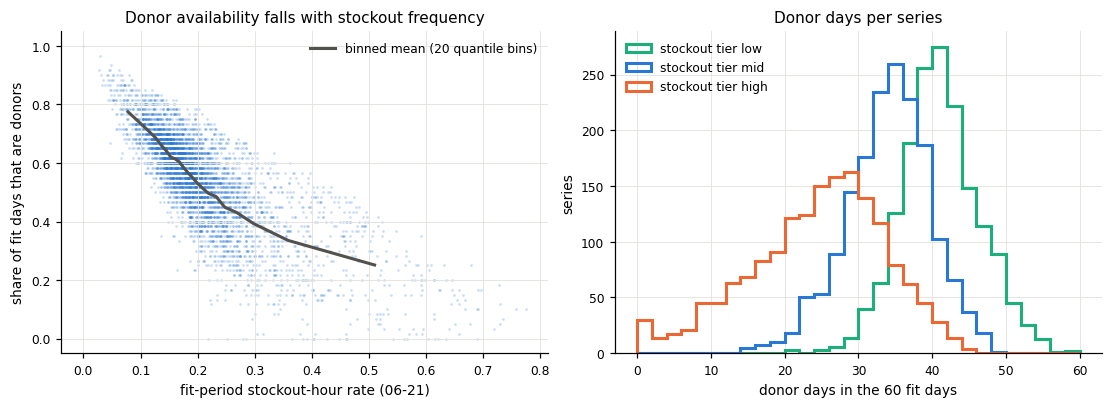

correlation(stockout rate, donor share) = -0.764


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
x = SERIES.fit_stockout_rate.values; yv = SERIES.donors_model_fit.values / 60
ax[0].scatter(x, yv, s=3, alpha=0.25, color=COL["A"], linewidths=0)
bins = np.quantile(x, np.linspace(0, 1, 21)); bi = np.clip(np.digitize(x, bins[1:-1]), 0, 19)
bm = pd.DataFrame({"b": bi, "x": x, "y": yv}).groupby("b").mean()
ax[0].plot(bm.x, bm.y, color=COL["real"], lw=2, label="binned mean (20 quantile bins)")
ax[0].set_xlabel("fit-period stockout-hour rate (06-21)"); ax[0].set_ylabel("share of fit days that are donors")
ax[0].set_title("Donor availability falls with stockout frequency"); ax[0].legend()
fitd = SERIES.donors_model_fit.values
for t, c in zip(["low", "mid", "high"], [COL["C"], COL["A"], COL["B"]]):
    ax[1].hist(fitd[SERIES.stockout_tier == t], bins=np.arange(0, 62, 2), histtype="step", lw=2, color=c, label=f"stockout tier {t}")
ax[1].set_xlabel("donor days in the 60 fit days"); ax[1].set_ylabel("series"); ax[1].set_title("Donor days per series"); ax[1].legend()
savefig(fig, "p1_donors_vs_stockout.png")
corr = np.corrcoef(x, yv)[0, 1]
print(f"correlation(stockout rate, donor share) = {corr:.3f}")

### Frequently stocked-out series with very few complete days
These series matter most: their demand is censored most often, and they have the fewest clean labels. The Phase 4 models share information across series through category, tier and lag features. They do not fit one isolated model per product.

In [19]:
scarce = SERIES[(SERIES.stockout_tier == "high")].copy()
sc_tab = pd.DataFrame({
    "threshold": ["<=5 fit donors", "<=10 fit donors", "0 tuning donors", "<=2 calibration donors"],
    "high-stockout-tier series": [(scarce.donors_model_fit <= 5).sum(), (scarce.donors_model_fit <= 10).sum(), (scarce.donors_tuning == 0).sum(), (scarce.donors_calibration <= 2).sum()],
    "all selected series": [(SERIES.donors_model_fit <= 5).sum(), (SERIES.donors_model_fit <= 10).sum(), (SERIES.donors_tuning == 0).sum(), (SERIES.donors_calibration <= 2).sum()]})
sc_tab["share of high tier"] = (sc_tab["high-stockout-tier series"] / max(len(scarce), 1)).round(3)
display(sc_tab)
display(scarce.sort_values("donors_model_fit").head(8)[["key", "first_category_id", "sales_tier", "fit_stockout_rate", "fit_mean_y16", "donors_model_fit", "donors_tuning", "donors_calibration"]].round(3))
sc_tab.to_csv(OUT / "metrics" / "scarce_donor_series.csv", index=False)

,threshold,high-stockout-tier series,all selected series,share of high tier
0,<=5 fit donors,61,61,0.036
1,<=10 fit donors,153,153,0.091
2,0 tuning donors,36,37,0.021
3,<=2 calibration donors,152,226,0.090


,key,first_category_id,sales_tier,fit_stockout_rate,fit_mean_y16,donors_model_fit,donors_tuning,donors_calibration
2374,750821,16,mid,0.392,0.534,0,0,0
3044,4882267,21,high,0.567,10.723,0,1,4
3172,6473224,16,mid,0.219,0.735,0,0,1
3159,6470224,16,mid,0.285,0.592,0,0,2
3600,11634224,16,high,0.459,0.902,0,0,0
3039,4881267,21,high,0.604,9.225,0,1,6
3009,4863267,21,high,0.543,9.910,0,3,3
3126,6362226,16,high,0.252,1.102,0,0,0


### Past-only features
Features are computed on a *timeline*: an array of visible hourly sales and stock flags for every day. In this phase that is the **real recorded** timeline. Phase 2 creates the simulated A/B/C timelines, and every timeline-dependent feature is recomputed on each one.

| Group | Features | Latest source day |
|---|---|---|
| Sales lags / rolls | lags 1, 2, 7, 14; means of the previous 7/14/28 days; 14-day std; expanding mean; same-weekday mean (lags 7/14/21); donor-only 14/28-day means | t−1 |
| Stockout history | stockout hours yesterday; 7/14-day and expanding stockout-hour rates; 7-day donor share; yesterday's first stockout slot; morning sales share yesterday | t−1 |
| Missing-lag indicators | `*_na` flags. Missing lags stay NaN (LightGBM routes them) and are never filled from future rows | t−1 |
| Tiers | sales/stockout tier of the series' *past* expanding mean, using the fit-period tertile edges | t−1 (edges are a documented global constant) |
| Past context | yesterday's discount, activity flag, holiday flag, precipitation, temperature, humidity, wind; 7-day discount/activity means | t−1 |
| Known calendar | day of week, weekend, official PRC holiday and make-up workday from the pre-published 2024 schedule | known at t−1 |
| Static IDs | city, store, product, management group, category levels 1–3, all **categorical** | time-invariant |

**Excluded from the primary forecast:** target-day `activity_flag`, `discount`, measured weather, and `holiday_flag`. The release does not establish when these became known. The target day's holiday status is instead represented by the pre-published calendar.

In [20]:
with stage("P1 real-timeline features"):
    FEAT_DAYS = np.arange(7, 75)        # fit rows from day 8 (so lag-7 exists) to day 60, tuning rows days 61-75
    REAL_TL = {"vis16": P["H"][:, :, H16], "flag16": P["S"][:, :, H16]}
    FR = build_features(REAL_TL["vis16"], REAL_TL["flag16"], P, SERIES, FEAT_DAYS)
print("feature table (real timeline):", FR.shape)
print(FR.dtypes.value_counts().to_string())
display(FR.describe().T.round(3).head(45))

[stage] P1 real-timeline features: 0.7s, peak RSS 1.00 GB
feature table (real timeline): (340000, 48)
float32    39
int32       8
int16       1


,count,mean,std,min,25%,50%,75%,max
sid,340000.0,2499.500,1443.378,0.00,1249.750,2499.500,3749.250,4999.000
d,340000.0,40.500,19.628,7.00,23.750,40.500,57.250,74.000
y_lag1,340000.0,0.933,1.275,0.00,0.400,0.600,1.100,31.000
y_lag2,340000.0,0.928,1.265,0.00,0.400,0.600,1.100,30.400
y_lag7,340000.0,0.919,1.238,0.00,0.400,0.600,1.000,29.900
y_lag14,305000.0,0.911,1.210,0.00,0.370,0.600,1.000,29.900
y_roll7,340000.0,0.925,1.129,0.00,0.429,0.614,1.000,26.214
y_roll14,340000.0,0.915,1.089,0.00,0.440,0.607,0.979,25.200
y_roll28,340000.0,0.895,1.016,0.00,0.439,0.600,0.961,24.496
y_std14,340000.0,0.399,0.408,0.00,0.202,0.280,0.439,8.127


### Exit check: provenance of every feature
For every feature, the latest permitted source date is computed from the registry for **every** row, and the notebook asserts it is earlier than the row's target date. Static IDs have no date. A name check also asserts that no forbidden target-day field is used as a feature.

In [21]:
tgt_dates = DATES[FR.d.values]
prov = []
for f in FEATURES:
    r = FEATURE_REGISTRY[f]; off = r["latest_source_offset_days"]
    if off is None:
        ok = True; latest = "n/a (static)"
    else:
        src = tgt_dates + np.timedelta64(off, "D"); ok = bool((src < tgt_dates).all()); latest = f"t{off:+d}"
    prov.append({"feature": f, "source": r["source"], "latest_permitted_source": latest, "note": r["note"], "all_rows_before_target": ok})
PROV = pd.DataFrame(prov)
PROV.to_csv(OUT / "manifests" / "feature_provenance.csv", index=False)
display(PROV)
ex = FR.sample(3, random_state=SEED)[["sid", "d"]]
ex["target_date"] = DATES[ex.d.values]; ex["latest_source_date_timeline_feats"] = DATES[ex.d.values - 1]
display(ex)
gate("Phase 1", "every feature's latest source date < target date", PROV.all_rows_before_target.all(), f"{len(PROV)} features")
gate("Phase 1", "no forbidden target-day field used as a feature", not (set(FEATURES) & set(FORBIDDEN_TARGET_DAY)))
gate("Phase 1", "ID columns are categorical inputs", set(CAT_FEATS) <= set(FEATURES))

,feature,source,latest_permitted_source,note,all_rows_before_target
0,y_lag1,timeline visible hourly sales / stock flags (06-21),t-1,,True
1,y_lag2,timeline visible hourly sales / stock flags (06-21),t-1,,True
2,y_lag7,timeline visible hourly sales / stock flags (06-21),t-1,,True
3,y_lag14,timeline visible hourly sales / stock flags (06-21),t-1,,True
4,y_roll7,timeline visible hourly sales / stock flags (06-21),t-1,,True
5,y_roll14,timeline visible hourly sales / stock flags (06-21),t-1,,True
6,y_roll28,timeline visible hourly sales / stock flags (06-21),t-1,,True
7,y_std14,timeline visible hourly sales / stock flags (06-21),t-1,,True
8,y_exp,timeline visible hourly sales / stock flags (06-21),t-1,,True
9,y_dow_mean,timeline visible hourly sales / stock flags (06-21),t-1,,True


,sid,d,target_date,latest_source_date_timeline_feats
173842,2556,41,2024-05-08,2024-05-07
108785,1599,60,2024-05-27,2024-05-26
28402,417,53,2024-05-20,2024-05-19


  [PASS] Phase 1 | every feature's latest source date < target date — 46 features
  [PASS] Phase 1 | no forbidden target-day field used as a feature 
  [PASS] Phase 1 | ID columns are categorical inputs 


True

### Exit check: automated target-day leakage test
Day 66 (a tuning date) gets random values for **all** of its outcome, stock and context fields: hourly sales, sale amount, stock flags, stock count, discount, activity, holiday and weather. Timelines and features are then rebuilt. Every day-66 feature must be bit-identical. As a power check, day-67 features, which may legitimately use day 66, must change.

In [22]:
with stage("P1 leakage perturbation test"):
    rows = np.arange(min(N_SERIES, 2000))
    Psub = subset_panel(P, rows)
    LEAK = leakage_perturbation_test(Psub, SERIES.iloc[rows].reset_index(drop=True), PRM_SMOKE, d0=65)
    # also on the real recorded timeline
    P2 = perturbed_copy(Psub, 65, SEED)
    fa = build_features(Psub["H"][:, :, H16], Psub["S"][:, :, H16], Psub, SERIES.iloc[rows].reset_index(drop=True), [65, 66])
    fb = build_features(P2["H"][:, :, H16], P2["S"][:, :, H16], P2, SERIES.iloc[rows].reset_index(drop=True), [65, 66])
    same_real, _ = frames_equal(fa[fa.d == 65], fb[fb.d == 65], FEATURES)
    _, dn = frames_equal(fa[fa.d == 66], fb[fb.d == 66], TL_FEATS + CTX_FEATS)
    LEAK = pd.concat([pd.DataFrame([{"mechanism": "real", "target_day_features_unchanged": same_real, "next_day_rows_changed_share": float(dn.mean())}]), LEAK])
    del Psub, P2, fa, fb; free_mem()
display(LEAK)
LEAK.to_csv(OUT / "metrics" / "leakage_perturbation_test.csv", index=False)
gate("Phase 1", "perturbing ALL target-day fields leaves target-day features unchanged (real, A, B, C)", LEAK.target_day_features_unchanged.all())
gate("Phase 1", "power check: next-day features do change", (LEAK.next_day_rows_changed_share > 0.5).all(), LEAK.next_day_rows_changed_share.round(3).tolist())

[stage] P1 leakage perturbation test: 3.0s, peak RSS 1.09 GB


,mechanism,target_day_features_unchanged,next_day_rows_changed_share
0,real,True,1.0
0,A,True,1.0
1,B,True,1.0
2,C,True,1.0


  [PASS] Phase 1 | perturbing ALL target-day fields leaves target-day features unchanged (real, A, B, C) 
  [PASS] Phase 1 | power check: next-day features do change — [1.0, 1.0, 1.0, 1.0]


True

### Manually inspected series histories
Three series are shown, one from each stockout tier. Each panel plots recorded 16-hour sales per day, marks stocked-out days, and overlays the 7-day past mean feature. Below the panels, raw rows give a digit-by-digit check that `y_lag1` for day *t* equals the recorded `y16` of day *t−1*.

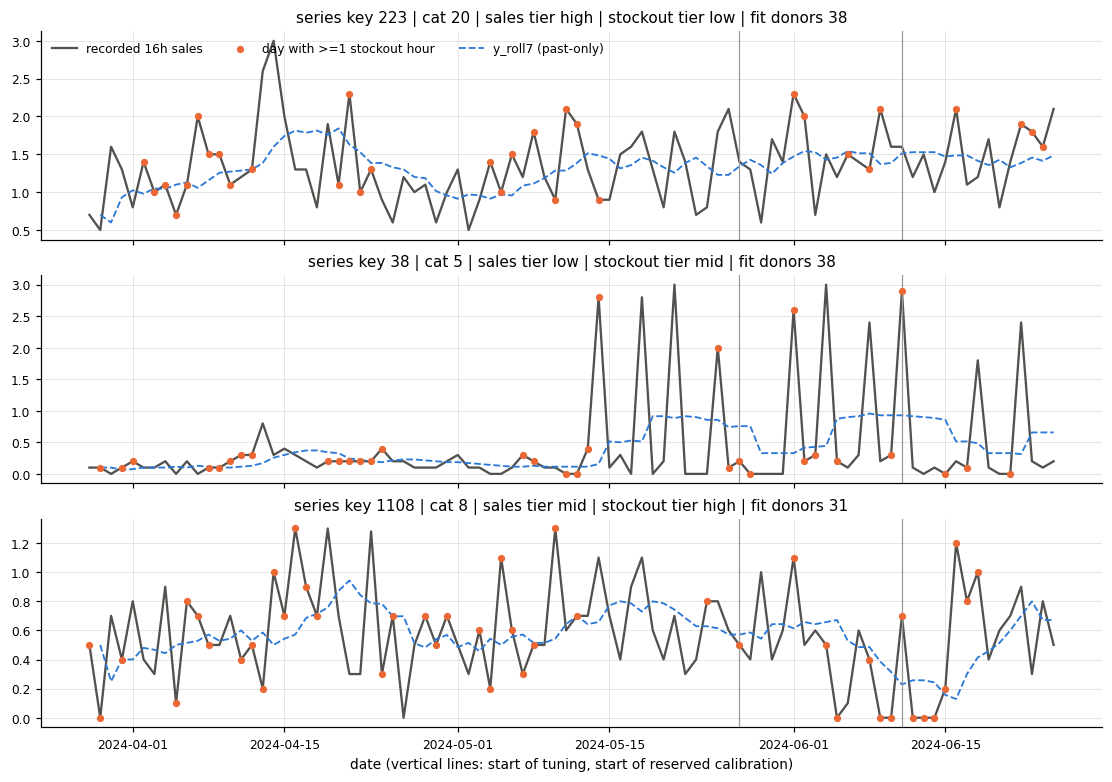

,sid,d,y_lag1,y_lag7,so_lag1,y_roll7,recorded_y16_day_t-1,recorded_y16_day_t-7,recorded_so_t-1,target_date
598,8,61,0.5,0.7,11.0,0.585714,0.5,0.7,11,2024-05-28
599,8,62,0.4,0.3,0.0,0.542857,0.4,0.3,0,2024-05-29
600,8,63,1.0,0.4,0.0,0.642857,1.0,0.4,0,2024-05-30


  [PASS] Phase 1 | manual history check: y_lag1/y_lag7/so_lag1 match recorded t-1/t-7 values 


,phase,check,status,detail
0,Phase 1,"no duplicate (series, dt) keys [global and sample]",PASS,
1,Phase 1,no nulls [global and sample],PASS,
2,Phase 1,sales nonnegative [global and sample],PASS,
3,Phase 1,all hourly arrays have 24 positions,PASS,
4,Phase 1,|sum(hours_sale) - sale_amount| <= 1e-05,PASS,max diff 7.11e-15
5,Phase 1,stock_hour6_22_cnt == sum(hours_stock_status[6:22]),PASS,
6,Phase 1,"stock status values are binary {0,1}",PASS,
7,Phase 1,every feature's latest source date < target date,PASS,46 features
8,Phase 1,no forbidden target-day field used as a feature,PASS,
9,Phase 1,ID columns are categorical inputs,PASS,


==== Phase 1 EXIT GATE: PASS (13/13 checks passed) ====


In [23]:
picks = [SERIES[SERIES.stockout_tier == t].sid.values[0] for t in ["low", "mid", "high"]]
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, s in zip(axs, picks):
    yv = P["Y16"][s]; so = P["SO16"][s]
    ax.plot(DATES, yv, color=COL["real"], lw=1.5, label="recorded 16h sales")
    ax.scatter(DATES[so > 0], yv[so > 0], s=14, color=COL["B"], zorder=3, label="day with >=1 stockout hour")
    r7 = roll_mean_past(P["Y16"][s:s + 1], 7)[0]; ax.plot(DATES, r7, color=COL["A"], lw=1.2, ls="--", label="y_roll7 (past-only)")
    for d0, c in [(60, "tuning"), (75, "calibration")]:
        ax.axvline(DATES[d0], color="#999", lw=0.8)
    row = SERIES.iloc[s]
    ax.set_title(f"series key {row.key} | cat {row.first_category_id} | sales tier {row.sales_tier} | stockout tier {row.stockout_tier} | fit donors {row.donors_model_fit}")
axs[0].legend(ncol=3, loc="upper left"); axs[-1].set_xlabel("date (vertical lines: start of tuning, start of reserved calibration)")
savefig(fig, "p1_series_histories.png")
s = picks[2]
chk = FR[(FR.sid == s) & FR.d.isin([61, 62, 63])][["sid", "d", "y_lag1", "y_lag7", "so_lag1", "y_roll7"]].copy()
chk["recorded_y16_day_t-1"] = P["Y16"][s, chk.d.values - 1]; chk["recorded_y16_day_t-7"] = P["Y16"][s, chk.d.values - 7]
chk["recorded_so_t-1"] = P["SO16"][s, chk.d.values - 1]; chk["target_date"] = DATES[chk.d.values]
display(chk)
gate("Phase 1", "manual history check: y_lag1/y_lag7/so_lag1 match recorded t-1/t-7 values",
     np.allclose(chk.y_lag1, chk["recorded_y16_day_t-1"], atol=1e-4) and np.allclose(chk.y_lag7, chk["recorded_y16_day_t-7"], atol=1e-4) and np.allclose(chk.so_lag1, chk["recorded_so_t-1"]))
FR.to_parquet(OUT / "data" / "features_real.parquet", index=False)
del FR, Sh, Hh, DAILY; free_mem()
P1_STATUS = gate_summary("Phase 1")

# Phase 2 — Three demand-dependent stockout mechanisms and three historical timelines

**Plain language.** Real stocked-out days hide how much customers wanted. Complete donor days do not, so they serve as controlled examples. On each donor day the simulator pretends the store opened with a limited, randomly drawn stock. The day's hourly donor demand then eats through that stock hour by hour, and whatever demand arrives after the shelf is empty is lost. Visible sales can therefore never exceed demand or stock. Applying this to every past donor day produces three alternative *histories* of what a forecaster would have seen:

| Mechanism | Opening stock on a donor day *t* (all inputs known by *t−1*) | Within-day refill |
|---|---|---|
| **A** ordinary depletion | `Q = max(μ_t · k · exp(σ·z), floor)`, where `μ_t` is the mean *recorded* 16h sales on days t−14..t−1 | yes: with prob. `p_refill`, one refill of `0.5·Q` arrives 1–3 h after the first stockout |
| **B** promotion-sensitive | as A, but on days in the declared promotion scenario (`activity_flag = 1`, used **retrospectively**) `k` is multiplied by `promo_factor = 0.6`. The retailer under-stocks relative to promotion demand, so high early demand sells out sooner | as A |
| **C** sustained scarcity | `k_C = 0.5·k`, `σ_C = 0.25` on every donor day: persistently low stock | **none** |

`z` is a standard normal draw from the counter-based generator; A/B/C use the same draws (common random numbers). `k` and `σ` are fitted **on fit dates only**, by matching observable real stockout patterns, and then checked on tuning dates. `promo_factor`, `k_C`/`σ_C`, the refill size and the floor are **predeclared** scenario constants; they are not fitted. The activity flag has no verified advance-plan timestamp, so it defines B's scenario only and is **never** a target-day forecast input.

Genuinely censored real days (≥1 flagged hour) stay exactly as recorded on every timeline. Their true demand is unknown and is never invented. Day 1 has no pre-day history (`μ` undefined), so it is not simulated.

In [24]:
with stage("P2 simulator fit (fit dates) + tuning check"):
    fit_mask = np.isin(np.arange(N_DAYS), FIT_D); tune_mask = np.isin(np.arange(N_DAYS), TUNE_D)
    REAL_FIT, REAL_TUNE = real_patterns(P, fit_mask), real_patterns(P, tune_mask)
    base = dict(p_refill=round(REAL_FIT["recovery"], 4), refill_frac=0.5, promo_factor=0.6, q_floor=0.1)
    grid = []
    for k in [0.8, 1.0, 1.25, 1.5, 2.0, 2.5]:
        for sig in [0.25, 0.5, 0.8]:
            prm = dict(base, k=k, sigma=sig, k_C=0.5 * k, sigma_C=0.25)
            sf = simulate(P, "A", prm, fit_mask, full_timeline=False); st = simulate(P, "A", prm, tune_mask, full_timeline=False)
            pf = pattern_stats(sf["vis_e"], sf["flag_e"]); pt = pattern_stats(st["vis_e"], st["flag_e"])
            grid.append({"k": k, "sigma": sig, "fit_loss": pattern_loss(REAL_FIT, pf), "tune_loss": pattern_loss(REAL_TUNE, pt),
                         "fit_rate_partial": pf["rate_partial"], "fit_mean_first": pf["first"].mean(), "fit_mean_dur": pf["dur"].mean()})
    SIMGRID = pd.DataFrame(grid).sort_values("fit_loss").reset_index(drop=True)
    best = SIMGRID.iloc[0]
    adjusted = False
    if best.tune_loss > 1.5 * best.fit_loss:          # predeclared adjustment rule using tuning dates
        best = SIMGRID.head(5).sort_values("tune_loss").iloc[0]; adjusted = True
    PRM = dict(base, k=float(best.k), sigma=float(best.sigma), k_C=0.5 * float(best.k), sigma_C=0.25)
SIMGRID.to_csv(OUT / "sim" / "simulator_grid_fit_dates.csv", index=False)
display(SIMGRID.round(4))
print("real fit-date patterns : partial-stockout rate %.3f, mean first slot %.2f, mean outage %.2f h, recovery %.3f" %
      (REAL_FIT["rate_partial"], REAL_FIT["first"].mean(), REAL_FIT["dur"].mean(), REAL_FIT["recovery"]))
print("real tuning patterns   : partial-stockout rate %.3f, mean first slot %.2f, mean outage %.2f h" % (REAL_TUNE["rate_partial"], REAL_TUNE["first"].mean(), REAL_TUNE["dur"].mean()))
print("selected simulator parameters:", PRM, "| adjusted using tuning dates:", adjusted)
json.dump({"params": PRM, "adjusted_on_tuning": adjusted, "selection": "min fit-date pattern loss; if tuning loss > 1.5x fit loss pick best tuning loss among top-5",
           "loss": "|partial-rate diff| + W1(first slot)/16 + W1(outage hours)/16 + W1(pre-stockout sales share)",
           "predeclared": ["promo_factor=0.6", "k_C=0.5k", "sigma_C=0.25", "refill_frac=0.5", "q_floor=0.1", "refill lag U{1,2,3}"],
           "p_refill": "plug-in: real within-day recovery share on fit dates"}, open(OUT / "sim" / "simulator_params.json", "w"), indent=2)

[stage] P2 simulator fit (fit dates) + tuning check: 4.2s, peak RSS 0.81 GB


,k,sigma,fit_loss,tune_loss,fit_rate_partial,fit_mean_first,fit_mean_dur
0,1.00,0.25,0.2346,0.2398,0.4626,15.0055,6.4442
1,1.25,0.50,0.2596,0.2381,0.3455,14.7586,6.7085
2,1.00,0.50,0.2945,0.3031,0.4613,14.2938,7.1717
3,1.25,0.25,0.3073,0.2966,0.3117,15.5438,5.9352
4,1.50,0.50,0.3313,0.3104,0.2570,15.0732,6.4035
5,1.25,0.80,0.3738,0.3450,0.3749,13.8200,7.6716
6,1.50,0.80,0.3930,0.3611,0.3067,14.0845,7.3965
7,2.00,0.80,0.4233,0.3933,0.2115,14.4482,7.0323
8,0.80,0.25,0.4331,0.4428,0.6096,14.3658,7.0740
9,1.50,0.25,0.4448,0.4345,0.2046,15.8414,5.6602


real fit-date patterns : partial-stockout rate 0.411, mean first slot 14.59, mean outage 6.39 h, recovery 0.147
real tuning patterns   : partial-stockout rate 0.370, mean first slot 14.81, mean outage 6.10 h
selected simulator parameters: {'p_refill': 0.1474, 'refill_frac': 0.5, 'promo_factor': 0.6, 'q_floor': 0.1, 'k': 1.0, 'sigma': 0.25, 'k_C': 0.5, 'sigma_C': 0.25} | adjusted using tuning dates: False


In [25]:
tier_of_sid = SERIES.stockout_tier.values
real_part_dur = {t: np.quantile(pattern_stats(P["H"][:, :, H16][(tier_of_sid == t)[:, None] & fit_mask[None, :]],
                                              P["S"][:, :, H16][(tier_of_sid == t)[:, None] & fit_mask[None, :]])["dur"], 0.95) for t in ["low", "mid", "high"]}
# Mechanisms are processed one at a time to bound memory: simulate -> invariant checks that need the full timeline ->
# rebuild ALL past-only features on this timeline and save them -> drop the full hourly timeline (donor-row arrays are kept).
TL, SIMCHK, VIS_Y, VIS_SO = {}, {}, {}, {}
with stage("P2 simulate A/B/C timelines + rebuild features per timeline"):
    for m in MECHS:
        r = simulate(P, m, PRM)
        r2 = simulate(P, m, PRM, full_timeline=False)                     # independent re-run for the determinism check
        SIMCHK[(m, "repro")] = np.array_equal(r["flag_e"], r2["flag_e"]) and np.array_equal(r["Q"], r2["Q"])
        del r2
        nd = ~r["elig"]
        SIMCHK[(m, "censored_as_recorded")] = bool(np.array_equal(r["vis16"][nd], P["H"][:, :, H16][nd]) and np.array_equal(r["flag16"][nd], P["S"][:, :, H16][nd]))
        y, so, _, _ = daily_view(r["vis16"], r["flag16"])
        VIS_Y[m], VIS_SO[m] = y, so
        F = build_features(r["vis16"], r["flag16"], P, SERIES, FEAT_DAYS)
        F["y_visible"] = y[F.sid.values, F.d.values].astype(np.float32)     # this timeline's visible 16h sales on the target day
        F["so_visible"] = so[F.sid.values, F.d.values].astype(np.float32)
        F["real_donor"] = P["DONOR"][F.sid.values, F.d.values]
        F["proxy_demand"] = np.where(F.real_donor, P["Y16"][F.sid.values, F.d.values], np.nan)   # evaluator/label column, donors only
        F.to_parquet(OUT / "data" / f"features_{m}.parquet", index=False)
        del F, nd
        r.pop("vis16"); r.pop("flag16"); TL[m] = r; free_mem()
SIMREC = {}
for m in MECHS:
    r = TL[m]; si, di = r["idx"]
    first = np.where(r["first_e"] >= 0, r["first_e"] + 6, -1)
    stress = r["dur_e"] > np.array([real_part_dur[t] for t in tier_of_sid[si]])
    rec = pd.DataFrame({"sid": si.astype(np.int32), "d": di.astype(np.int16), "dt": DATES[di], "split": SPLIT_OF_DAY[di],
                        "opening_stock_Q": r["Q"], "first_stockout_hour": first.astype(np.int8), "outage_hours": r["dur_e"].astype(np.int8),
                        "masked": r["dur_e"] > 0, "visible_total": r["vis_e"].sum(1),
                        "promo_scenario_day": P["CTX"]["activity_flag"][si, di] == 1,
                        "stress_outside_observed_support": stress,
                        "EVALUATOR_ONLY_donor_proxy_total": r["demand_e"]})
    for h in range(16):
        rec[f"vis_h{h+6:02d}"] = r["vis_e"][:, h].astype(np.float32)
    rec.to_parquet(OUT / "sim" / f"sim_records_{m}.parquet", index=False)
    SIMREC[m] = rec.drop(columns=[f"vis_h{h+6:02d}" for h in range(16)])      # hourly columns stay on disk only
    del rec
summ = pd.DataFrame({m: {"eligible donor days": len(SIMREC[m]), "masked (>=1 simulated stockout hour)": int(SIMREC[m].masked.sum()),
                         "masked share": SIMREC[m].masked.mean(), "mean outage hours | masked": SIMREC[m].loc[SIMREC[m].masked, "outage_hours"].mean(),
                         "visible / proxy total": SIMREC[m].visible_total.sum() / SIMREC[m].EVALUATOR_ONLY_donor_proxy_total.sum(),
                         "promo-scenario masked share": SIMREC[m].loc[SIMREC[m].promo_scenario_day, "masked"].mean(),
                         "non-promo masked share": SIMREC[m].loc[~SIMREC[m].promo_scenario_day, "masked"].mean(),
                         "stress (outage > real p95 of tier)": SIMREC[m].stress_outside_observed_support.mean()} for m in MECHS})
display(summ.round(4))
summ.to_csv(OUT / "sim" / "simulation_summary.csv")

[stage] P2 simulate A/B/C timelines + rebuild features per timeline: 5.8s, peak RSS 0.97 GB


,A,B,C
eligible donor days,248739.0000,248739.0000,248739.0000
masked (>=1 simulated stockout hour),114337.0000,140861.0000,206995.0000
masked share,0.4597,0.5663,0.8322
mean outage hours | masked,6.3866,7.2889,9.1743
visible / proxy total,0.8032,0.7184,0.4740
promo-scenario masked share,0.5115,0.8083,0.8690
non-promo masked share,0.4306,0.4306,0.8115
stress (outage > real p95 of tier),0.0213,0.0483,0.1448


### Exit checks: simulator invariants

In [26]:
for m in MECHS:
    r = TL[m]; dem = P["H"][:, :, H16][r["idx"]].astype(np.float64)
    cap = r["Q"] * (1 + (PRM["refill_frac"] if m in ("A", "B") else 0.0))
    gate("Phase 2", f"{m}: visible hourly sales <= donor hourly demand", (r["vis_e"] <= dem + 1e-9).all())
    gate("Phase 2", f"{m}: visible daily sales <= opening stock (+ single refill for A/B)", (r["vis_e"].astype(np.float64).sum(1) <= cap + 1e-5 * np.maximum(cap, 1)).all(), "float32 storage tolerance 1e-5 relative")
    gate("Phase 2", f"{m}: unmasked donor days keep visible == demand", np.allclose(r["vis_e"][r["dur_e"] == 0], dem[r["dur_e"] == 0]))
    gate("Phase 2", f"{m}: masks and stock reproduce with the seed", SIMCHK[(m, "repro")])
    gate("Phase 2", f"{m}: genuinely censored / non-eligible days left as recorded", SIMCHK[(m, "censored_as_recorded")])
    del dem
same_ids = all(np.array_equal(SIMREC["A"][["sid", "d"]].values, SIMREC[m][["sid", "d"]].values) for m in MECHS)
same_proxy = all(np.array_equal(SIMREC["A"].EVALUATOR_ONLY_donor_proxy_total.values, SIMREC[m].EVALUATOR_ONLY_donor_proxy_total.values) for m in MECHS)
gate("Phase 2", "identical eligible donor IDs across A/B/C", same_ids, len(SIMREC["A"]))
gate("Phase 2", "identical donor proxy demand across A/B/C", same_proxy)
v, f, _ = deplete(np.array([[2, 3, 4, 1]]), np.array([6.0]))
gate("Phase 2", "hand example passes", v[0].tolist() == [2, 3, 1, 0] and v.sum() == 6)
free_mem();

  [PASS] Phase 2 | A: visible hourly sales <= donor hourly demand 
  [PASS] Phase 2 | A: visible daily sales <= opening stock (+ single refill for A/B) — float32 storage tolerance 1e-5 relative
  [PASS] Phase 2 | A: unmasked donor days keep visible == demand 
  [PASS] Phase 2 | A: masks and stock reproduce with the seed 
  [PASS] Phase 2 | A: genuinely censored / non-eligible days left as recorded 
  [PASS] Phase 2 | B: visible hourly sales <= donor hourly demand 
  [PASS] Phase 2 | B: visible daily sales <= opening stock (+ single refill for A/B) — float32 storage tolerance 1e-5 relative
  [PASS] Phase 2 | B: unmasked donor days keep visible == demand 
  [PASS] Phase 2 | B: masks and stock reproduce with the seed 
  [PASS] Phase 2 | B: genuinely censored / non-eligible days left as recorded 
  [PASS] Phase 2 | C: visible hourly sales <= donor hourly demand 
  [PASS] Phase 2 | C: visible daily sales <= opening stock (+ single refill for A/B) — float32 storage tolerance 1e-5 relative
  

### Real vs simulated observable patterns
Real patterns come from **all** real days in a period. Simulated patterns come from the eligible donor days of the same period on each timeline. Three observables are compared, restricted to partial-stockout days (1–15 of 16 hours out): the first stockout hour, the outage length, and the share of the day's visible sales recorded before the first stockout. Fit dates were used to fit A; tuning dates are the out-of-period check. B and C are declared scenarios and are *expected* to differ from reality.

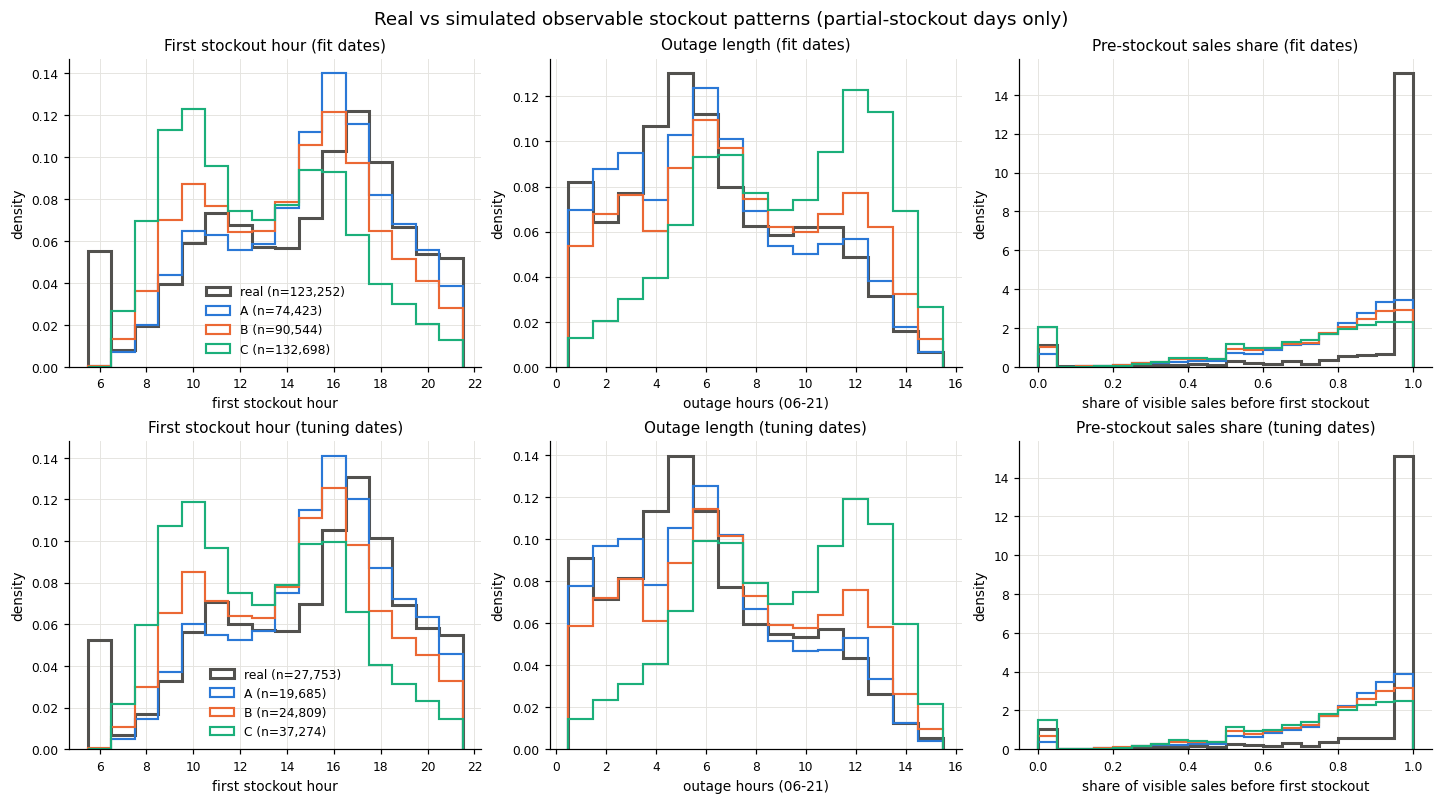

,source,period,rows,partial_stockout_rate,full_outage_rate,mean_first_hour,mean_outage_h,mean_pre_share,recovery_share,loss_vs_real
0,real,fit,300000,0.411,0.045,14.592,6.393,0.887,0.147,0.000
1,real,tuning,75000,0.370,0.029,14.811,6.101,0.888,0.153,0.000
2,A,fit,160869,0.463,0.001,15.006,6.444,0.770,0.130,0.235
3,A,tuning,45097,0.437,0.000,15.298,6.159,0.792,0.130,0.240
4,B,fit,160869,0.563,0.002,14.164,7.296,0.731,0.130,0.414
5,B,tuning,45097,0.550,0.001,14.361,7.095,0.752,0.132,0.436
6,C,fit,160869,0.825,0.006,12.826,9.174,0.675,0.000,0.926
7,C,tuning,45097,0.827,0.004,13.023,8.977,0.700,0.000,0.951


In [27]:
def sim_patterns(m, mask):
    r = TL[m]; sel = mask[r["idx"][1]]
    return pattern_stats(r["vis_e"][sel], r["flag_e"][sel])
PAT = {("real", "fit"): REAL_FIT, ("real", "tuning"): REAL_TUNE}
for m in MECHS:
    PAT[(m, "fit")] = sim_patterns(m, fit_mask); PAT[(m, "tuning")] = sim_patterns(m, tune_mask)
fig, axs = plt.subplots(2, 3, figsize=(13, 7.2))
for i, per in enumerate(["fit", "tuning"]):
    for j, (key, bins, lab) in enumerate([("first", np.arange(5.5, 22.5, 1), "first stockout hour"), ("dur", np.arange(0.5, 16.5, 1), "outage hours (06-21)"),
                                          ("pre_share", np.linspace(0, 1, 21), "share of visible sales before first stockout")]):
        ax = axs[i, j]
        for src in ["real"] + MECHS:
            ax.hist(PAT[(src, per)][key], bins=bins, density=True, histtype="step", lw=2 if src == "real" else 1.4, color=COL[src],
                    label=f"{src} (n={len(PAT[(src, per)][key]):,})")
        ax.set_title(f"{['First stockout hour', 'Outage length', 'Pre-stockout sales share'][j]} ({per} dates)"); ax.set_xlabel(lab); ax.set_ylabel("density")
        if j == 0: ax.legend()
fig.suptitle("Real vs simulated observable stockout patterns (partial-stockout days only)")
savefig(fig, "p2_real_vs_sim_patterns.png")
pat_tbl = pd.DataFrame([{"source": s, "period": p, "rows": v["n_rows"], "partial_stockout_rate": v["rate_partial"], "full_outage_rate": v["rate_full"],
                         "mean_first_hour": v["first"].mean(), "mean_outage_h": v["dur"].mean(), "mean_pre_share": v["pre_share"].mean(),
                         "recovery_share": v["recovery"], "loss_vs_real": (pattern_loss(PAT[("real", p)], v) if s != "real" else 0.0)}
                        for (s, p), v in PAT.items()])
display(pat_tbl.round(3)); pat_tbl.to_csv(OUT / "sim" / "real_vs_sim_patterns.csv", index=False)

,stockout_tier,period,source,partial_rate,mean_first,mean_dur,n_events,enough_support(>=200 events)
0,low,fit,real,0.308,14.896,5.873,30202,True
1,low,fit,A,0.433,15.227,6.220,28260,True
2,low,fit,B,0.532,14.357,7.099,34742,True
3,low,fit,C,0.815,12.964,9.036,53210,True
4,low,tuning,real,0.347,14.467,6.265,8504,True
5,low,tuning,A,0.421,15.291,6.154,6444,True
6,low,tuning,B,0.532,14.390,7.049,8138,True
7,low,tuning,C,0.817,13.027,8.973,12511,True
8,mid,fit,real,0.413,14.924,6.189,41789,True
9,mid,fit,A,0.454,15.095,6.359,25292,True


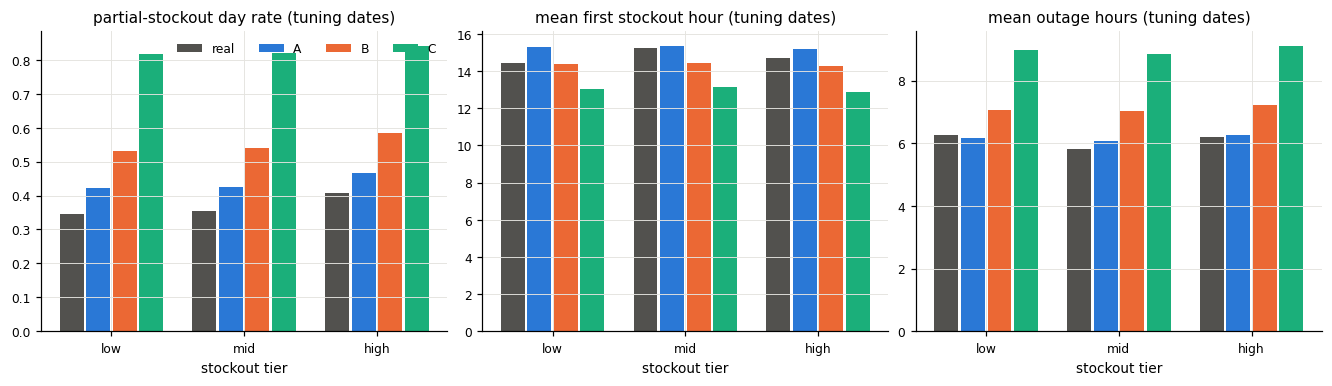

PosixPath('/home/claude/frn/frn_outputs/demo5000/figures/p2_real_vs_sim_by_tier.png')

In [28]:
rows = []
for t in ["low", "mid", "high"]:
    tm = tier_of_sid == t
    for per, mask in [("fit", fit_mask), ("tuning", tune_mask)]:
        rr = tm[:, None] & mask[None, :]
        rp = pattern_stats(P["H"][:, :, H16][rr], P["S"][:, :, H16][rr])
        rows.append({"stockout_tier": t, "period": per, "source": "real", "partial_rate": rp["rate_partial"], "mean_first": rp["first"].mean(), "mean_dur": rp["dur"].mean(), "n_events": len(rp["dur"])})
        for m in MECHS:
            r = TL[m]; sel = mask[r["idx"][1]] & tm[r["idx"][0]]
            sp = pattern_stats(r["vis_e"][sel], r["flag_e"][sel])
            rows.append({"stockout_tier": t, "period": per, "source": m, "partial_rate": sp["rate_partial"], "mean_first": sp["first"].mean() if len(sp["first"]) else np.nan,
                         "mean_dur": sp["dur"].mean() if len(sp["dur"]) else np.nan, "n_events": len(sp["dur"])})
STRAT = pd.DataFrame(rows); STRAT["enough_support(>=200 events)"] = STRAT.n_events >= 200
display(STRAT.round(3)); STRAT.to_csv(OUT / "sim" / "real_vs_sim_by_stockout_tier.csv", index=False)
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (col, lab) in zip(axs, [("partial_rate", "partial-stockout day rate"), ("mean_first", "mean first stockout hour"), ("mean_dur", "mean outage hours")]):
    sub = STRAT[STRAT.period == "tuning"]
    for i, src in enumerate(["real"] + MECHS):
        vals = sub[sub.source == src].set_index("stockout_tier").loc[["low", "mid", "high"], col]
        ax.bar(np.arange(3) + (i - 1.5) * 0.2, vals, width=0.18, color=COL[src], label=src)
    ax.set_xticks(range(3)); ax.set_xticklabels(["low", "mid", "high"]); ax.set_xlabel("stockout tier"); ax.set_title(lab + " (tuning dates)")
axs[0].legend(ncol=4)
savefig(fig, "p2_real_vs_sim_by_tier.png")

### Donor-selection bias
Donor days are selected because stock lasted all day. Selection is likely to favour quiet days and well-stocked series. The table compares donor with non-donor days on quantities known **before** the day, plus recorded sales. Recorded sales on non-donor days are censored, so they are only a lower bound on demand.

In [29]:
don = P["DONOR"]; fm = fit_mask[None, :] & np.ones_like(don)
rel = P["MU"] / np.nanmean(np.where(fit_mask[None, :], P["Y16"], np.nan), 1, keepdims=True)
rows = []
for lab, x in [("recorded 16h sales (non-donor = censored lower bound)", P["Y16"]), ("pre-day 14-day mean recorded sales (mu)", P["MU"]),
               ("pre-day level relative to series fit mean", rel), ("activity_flag (promotion scenario)", P["CTX"]["activity_flag"]),
               ("weekend", np.broadcast_to((((DATES.astype(np.int64) + 3) % 7) >= 5)[None, :], don.shape).astype(float))]:
    rows.append({"quantity (fit dates)": lab, "donor days": np.nanmean(x[don & fm]), "non-donor days": np.nanmean(x[~don & fm])})
BIAS = pd.DataFrame(rows); BIAS["ratio donor/non-donor"] = BIAS["donor days"] / BIAS["non-donor days"]
share_rows = pd.DataFrame({"share of all fit rows": pd.Series(np.repeat(tier_of_sid, 60)).value_counts(normalize=True),
                           "share of fit donor rows": pd.Series(np.repeat(tier_of_sid, 60)[don[:, :60].reshape(-1)]).value_counts(normalize=True)})
display(BIAS.round(4)); display(share_rows.round(4))
BIAS.to_csv(OUT / "metrics" / "donor_selection_bias.csv", index=False)
print("Interpretation: donor-trained demand models learn from days on which stock sufficed; busy/promotion days and high-stockout series are under-represented. Proxy labels may therefore understate demand on busy days.")

,quantity (fit dates),donor days,non-donor days,ratio donor/non-donor
0,recorded 16h sales (non-donor = censored lower bound),0.8737,0.9530,0.9168
1,pre-day 14-day mean recorded sales (mu),0.8430,0.9227,0.9136
2,pre-day level relative to series fit mean,0.9970,0.9373,1.0636
3,activity_flag (promotion scenario),0.3473,0.3867,0.8980
4,weekend,0.2911,0.3107,0.9368


,share of all fit rows,share of fit donor rows
high,0.3362,0.2474
low,0.3268,0.4062
mid,0.3370,0.3464


Interpretation: donor-trained demand models learn from days on which stock sufficed; busy/promotion days and high-stockout series are under-represented. Proxy labels may therefore understate demand on busy days.


### Three historical timelines: past-only features recomputed per timeline
All timeline-dependent features were rebuilt, in the simulation cell above, from each timeline's visible sales and flags. A forecast for day *t* sees only days ≤ *t−1* of its own timeline. The target donor IDs and proxy labels do not depend on the mechanism. The gate requires a *meaningful* fraction of past-only feature values to differ across timelines on tuning target donors: at least 5% of rows for `y_roll7`.

In [30]:
for m in MECHS:
    print(m, "feature table:", pq.ParquetFile(OUT / "data" / f"features_{m}.parquet").metadata.num_rows, "rows x",
          len(pq.ParquetFile(OUT / "data" / f"features_{m}.parquet").schema_arrow.names), "columns")

A feature table: 340000 rows x 52 columns
B feature table: 340000 rows x 52 columns
C feature table: 340000 rows x 52 columns


In [31]:
def load_feats(m, cols=None, filters=None):
    return pd.read_parquet(OUT / "data" / f"features_{m}.parquet", columns=cols, filters=filters)
tcols = ["sid", "d", "real_donor", "proxy_demand"] + TL_FEATS
FT = {m: load_feats(m, tcols, [("d", ">=", 60)]) for m in MECHS}          # tuning target rows only
FT["real"] = load_feats("real", ["sid", "d"] + TL_FEATS, [("d", ">=", 60)])
FT["real"]["real_donor"] = P["DONOR"][FT["real"].sid.values, FT["real"].d.values]
sel = {m: (FT[m].d >= 60) & FT[m].real_donor for m in FT}
diff_rows = []
for a_, b_ in [("A", "B"), ("A", "C"), ("B", "C"), ("real", "A"), ("real", "B"), ("real", "C")]:
    xa, xb = FT[a_][sel[a_]].reset_index(drop=True), FT[b_][sel[b_]].reset_index(drop=True)
    assert np.array_equal(xa[["sid", "d"]].values, xb[["sid", "d"]].values)
    r = {"pair": f"{a_} vs {b_}", "tuning target donors": len(xa)}
    for f in ["y_lag1", "y_lag7", "y_roll7", "y_roll28", "y_don_roll14", "so_lag1", "so_rate14", "don_frac7"]:
        _, dd = frames_equal(xa, xb, [f]); r[f] = dd.mean()
    _, dd = frames_equal(xa, xb, TL_FEATS); r["any timeline feature"] = dd.mean()
    diff_rows.append(r)
FEATDIFF = pd.DataFrame(diff_rows)
ids_same = all(np.array_equal(FT["A"][sel["A"]][["sid", "d"]].values, FT[m][sel[m]][["sid", "d"]].values) for m in MECHS)
lab_same = all(np.array_equal(FT["A"][sel["A"]].proxy_demand.values, FT[m][sel[m]].proxy_demand.values) for m in MECHS)
FEATDIFF["identical target donor IDs"] = ids_same; FEATDIFF["identical proxy labels"] = lab_same
display(FEATDIFF.round(3)); FEATDIFF.to_csv(OUT / "metrics" / "timeline_feature_differences.csv", index=False)
mech_pairs = FEATDIFF.iloc[:3]
gate("Phase 2", "same tuning target donor IDs and proxy labels across A/B/C feature tables", ids_same and lab_same)
gate("Phase 2", ">=5% of tuning target rows have different y_roll7 for every A/B/C pair", (mech_pairs.y_roll7 >= 0.05).all(), mech_pairs.y_roll7.round(3).tolist())
gate("Phase 2", "simulated timelines differ from the real recorded timeline", (FEATDIFF.iloc[3:]["any timeline feature"] > 0.05).all())
del FT; free_mem()

,pair,tuning target donors,y_lag1,y_lag7,y_roll7,y_roll28,y_don_roll14,so_lag1,so_rate14,don_frac7,any timeline feature,identical target donor IDs,identical proxy labels
0,A vs B,45097,0.199,0.177,0.412,0.617,0.360,0.183,0.471,0.280,0.728,True,True
1,A vs C,45097,0.586,0.546,0.978,0.999,0.948,0.569,0.996,0.836,1.000,True,True
2,B vs C,45097,0.585,0.546,0.978,0.999,0.796,0.484,0.989,0.657,1.000,True,True
3,real vs A,45097,0.303,0.294,0.873,0.997,0.973,0.303,0.974,0.873,0.999,True,True
4,real vs B,45097,0.382,0.361,0.910,0.998,0.982,0.383,0.983,0.910,1.000,True,True
5,real vs C,45097,0.586,0.547,0.979,0.999,0.997,0.588,0.997,0.979,1.000,True,True


  [PASS] Phase 2 | same tuning target donor IDs and proxy labels across A/B/C feature tables 
  [PASS] Phase 2 | >=5% of tuning target rows have different y_roll7 for every A/B/C pair — [0.412, 0.978, 0.978]
  [PASS] Phase 2 | simulated timelines differ from the real recorded timeline 


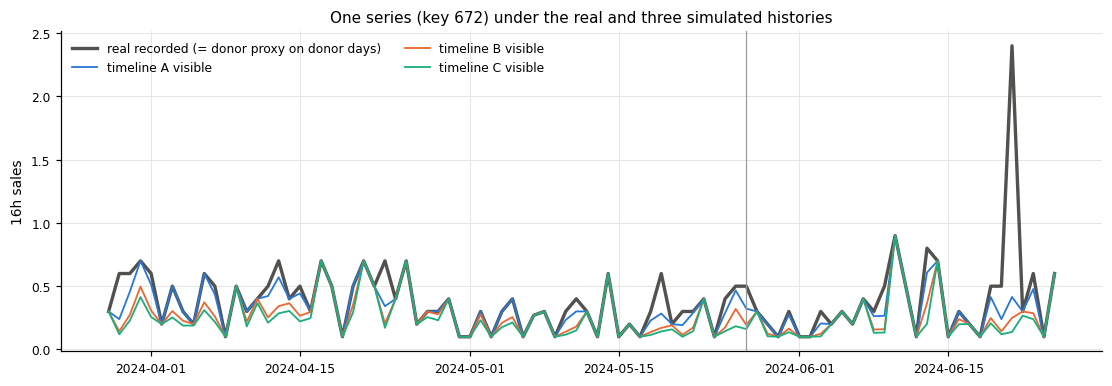

PosixPath('/home/claude/frn/frn_outputs/demo5000/figures/p2_timeline_example.png')

In [32]:
s = SERIES[(SERIES.stockout_tier == "low") & (SERIES.donors_model_fit >= 40)].sid.values[0]
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(DATES, P["Y16"][s], color=COL["real"], lw=2.2, label="real recorded (= donor proxy on donor days)")
for m in MECHS:
    ax.plot(DATES, VIS_Y[m][s], color=COL[m], lw=1.2, label=f"timeline {m} visible")
ax.axvline(DATES[60], color="#999", lw=0.8); ax.set_ylabel("16h sales"); ax.legend(ncol=2)
ax.set_title(f"One series (key {SERIES.key.iloc[s]}) under the real and three simulated histories")
savefig(fig, "p2_timeline_example.png")

### Phase 0 reproducibility gate (cross-run)
The selected series, split manifest and simulator masks are fingerprinted with SHA-256, and the result is appended to `repro_fingerprints.json`. When an earlier execution with the same seed, source hashes and configuration exists, the fingerprints must match exactly. The first execution in a fresh output folder cannot verify this, so it is recorded as **NOT YET VERIFIED** (counted as FAIL) instead of PASS.

In [33]:
for m in MECHS:
    r = TL[m]
    h = hashlib.sha256(); [h.update(np.ascontiguousarray(a).tobytes()) for a in (r["idx"][0], r["idx"][1], np.round(r["Q"], 10), r["flag_e"])]
    FINGERPRINTS[f"sim_mask_{m}_sha256"] = h.hexdigest()
FINGERPRINTS["source_sha256"] = {k: v["sha256"] for k, v in provenance["source_files"].items()}
FINGERPRINTS["config"] = {"SEED": SEED, "RUN_TAG": RUN_TAG, "SAMPLE_N_SERIES": SAMPLE_N_SERIES, "FULL_RUN": FULL_RUN}
fp_path = OUT / "manifests" / "repro_fingerprints.json"
hist = json.load(open(fp_path)) if fp_path.exists() else []
prior = [h for h in hist if h["fingerprints"]["config"] == FINGERPRINTS["config"] and h["fingerprints"]["source_sha256"] == FINGERPRINTS["source_sha256"]]
hist.append({"time_utc": dtm.datetime.utcnow().isoformat(timespec="seconds") + "Z", "fingerprints": FINGERPRINTS})
json.dump(hist, open(fp_path, "w"), indent=2)
print(json.dumps(FINGERPRINTS, indent=1))
def overlap_check(other_tag):
    """Cross-execution check against another run (demo vs full). The other run's fitted simulator parameters are
    re-applied here to the overlapping series; because draws come from a counter-based generator keyed by
    (seed, series key, day), the resulting masks must equal the other execution's saved masks exactly."""
    od = OUT.parent / other_tag
    need = [od / "run_status.json", od / "sim" / "sim_records_C.parquet", od / "sim" / "simulator_params.json", od / "manifests" / "repro_fingerprints.json"]
    if other_tag == RUN_TAG or not all(p.exists() for p in need):
        return None
    ok_keys = pd.read_parquet(od / "manifests" / "selected_series.parquet", columns=["key"]).key.values
    common = np.intersect1d(SERIES.key.values, ok_keys)
    oprm = json.load(open(od / "sim" / "simulator_params.json"))["params"]
    ofp = json.load(open(od / "manifests" / "repro_fingerprints.json"))[-1]["fingerprints"]
    res = {"other_run": other_tag, "overlap_series": int(len(common)), "same_fitted_params": oprm == PRM,
           "split_manifest_match": ofp["split_manifest_sha256"] == FINGERPRINTS["split_manifest_sha256"]}
    Psub = subset_panel(P, np.searchsorted(SERIES.key.values, common))
    cols = ["sid", "d", "opening_stock_Q", "first_stockout_hour", "outage_hours"]
    for m in MECHS:
        r = simulate(Psub, m, oprm, full_timeline=False)
        mine = pd.DataFrame({"key": common[r["idx"][0]], "d": r["idx"][1], "Q": r["Q"], "dur": r["dur_e"],
                             "first": np.where(r["first_e"] >= 0, r["first_e"] + 6, -1)}).sort_values(["key", "d"])
        o = pd.read_parquet(od / "sim" / f"sim_records_{m}.parquet", columns=cols); o["key"] = ok_keys[o.sid.values]
        o = o[o.key.isin(common)].sort_values(["key", "d"])
        res[f"mask_{m}_identical_on_overlap"] = bool(len(o) == len(mine) and np.array_equal(o[["key", "d"]].values, mine[["key", "d"]].values)
            and np.array_equal(o.opening_stock_Q.values, mine.Q.values) and np.array_equal(o.outage_hours.values, mine.dur.values)
            and np.array_equal(o.first_stockout_hour.values, mine["first"].values))
        res[f"rows_compared_{m}"] = int(len(o))
    del Psub; free_mem()
    return res

other_tag = os.environ.get("FRN_OVERLAP_TAG") or (f"demo{SAMPLE_N_SERIES}" if FULL_RUN else "full50k")
OVL = overlap_check(other_tag)
if OVL:
    display(pd.Series(OVL).to_frame("value"))
    gate("Phase 0", f"split IDs and simulator masks (other run's parameters) identical to the {other_tag} execution on overlapping series",
         OVL["split_manifest_match"] and all(OVL[f"mask_{m}_identical_on_overlap"] for m in MECHS), f"{OVL['overlap_series']} overlapping series")
if prior:
    last = prior[-1]["fingerprints"]
    keys = ["selected_series_sha256", "split_manifest_sha256"] + [f"sim_mask_{m}_sha256" for m in MECHS]
    cmp = pd.DataFrame([{"item": k, "previous run": last.get(k, "")[:16], "this run": FINGERPRINTS[k][:16], "match": last.get(k) == FINGERPRINTS[k]} for k in keys])
    display(cmp); print(f"compared with {len(prior)} earlier execution(s); latest at {prior[-1]['time_utc']}")
    gate("Phase 0", "restart-and-run-all reproduces selected series, split IDs and simulator masks", cmp.match.all(), f"vs run at {prior[-1]['time_utc']}")
elif FULL_RUN and OVL and OVL["split_manifest_match"] and all(OVL[f"mask_{m}_identical_on_overlap"] for m in MECHS):
    gate("Phase 0", "restart-and-run-all reproduces selected series, split IDs and simulator masks", True,
         f"full run executed once; selection = all 50,000 series by rule; split IDs and masks re-verified against the independent {other_tag} execution on {OVL['overlap_series']} series")
else:
    gate("Phase 0", "restart-and-run-all reproduces selected series, split IDs and simulator masks", False, "NOT YET VERIFIED: first execution in this output folder")
P0_STATUS = gate_summary("Phase 0")
P2_STATUS = gate_summary("Phase 2")
del TL; free_mem()   # donor-row simulator arrays are saved in sim/sim_records_*.parquet
free_mem();

{
 "selected_series_sha256": "e6b44ed046aafbc98ce76f43d802e9f28f7238856579ee71a55999c75dbe4cfe",
 "split_manifest_sha256": "1510eb5d6d3ae0b8c98bc5323636c335f3f85bc6e64b6d9d8b4369826549ff06",
 "sim_mask_A_sha256": "cd5d1e3b8b0786a2456c38709e6411ed9623535d82d2cdc974485cbc134108b7",
 "sim_mask_B_sha256": "8ce929c5d803baaa488f8aa94c93e17196e1c5b4a6eee5b56750a49556f8ec70",
 "sim_mask_C_sha256": "3d854812bc4d9db7bc23e1b10dd08727ef8cbcee1f0a677ace3fa7171abd6e43",
 "source_sha256": {
  "train.parquet": "6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d",
  "eval.parquet": "1b118840664280c6b88bffc84c80ee1f54c05d911e354b7599e5da10995e960e"
 },
 "config": {
  "SEED": 20240628,
  "RUN_TAG": "demo5000",
  "SAMPLE_N_SERIES": 5000,
  "FULL_RUN": false
 }
}


,value
other_run,full50k
overlap_series,5000
same_fitted_params,False
split_manifest_match,True
mask_A_identical_on_overlap,True
rows_compared_A,248739
mask_B_identical_on_overlap,True
rows_compared_B,248739
mask_C_identical_on_overlap,True
rows_compared_C,248739


  [PASS] Phase 0 | split IDs and simulator masks (other run's parameters) identical to the full50k execution on overlapping series — 5000 overlapping series


,item,previous run,this run,match
0,selected_series_sha256,e6b44ed046aafbc9,e6b44ed046aafbc9,True
1,split_manifest_sha256,1510eb5d6d3ae0b8,1510eb5d6d3ae0b8,True
2,sim_mask_A_sha256,cd5d1e3b8b0786a2,cd5d1e3b8b0786a2,True
3,sim_mask_B_sha256,8ce929c5d803baaa,8ce929c5d803baaa,True
4,sim_mask_C_sha256,3d854812bc4d9db7,3d854812bc4d9db7,True


compared with 1 earlier execution(s); latest at 2026-09-20T16:09:38Z
  [PASS] Phase 0 | restart-and-run-all reproduces selected series, split IDs and simulator masks — vs run at 2026-09-20T16:09:38Z


,phase,check,status,detail
0,Phase 0,schema has all expected fields (train & eval),PASS,
1,Phase 0,"train rows == 4,500,000",PASS,4500000
2,Phase 0,"eval rows == 350,000",PASS,350000
3,Phase 0,eval dates are 2024-06-26..2024-07-02,PASS,
4,Phase 0,static category IDs constant within each series,PASS,
5,Phase 0,"50,000 series x 90 dates, no duplicate or missing keys",PASS,"series=50000, dup=0, missing=0"
6,Phase 0,series selection deterministic within session,PASS,
7,Phase 0,selected series count == 5000,PASS,5000
8,Phase 0,tier composition of sample within 1 pp of population,PASS,
9,Phase 0,"hand example [2,3,4,1] with stock 6 -> [2,3,1,0], total 6, proxy 10",PASS,


==== Phase 0 EXIT GATE: PASS (16/16 checks passed) ====


,phase,check,status,detail
0,Phase 2,A: visible hourly sales <= donor hourly demand,PASS,
1,Phase 2,A: visible daily sales <= opening stock (+ single refill for A/B),PASS,float32 storage tolerance 1e-5 relative
2,Phase 2,A: unmasked donor days keep visible == demand,PASS,
3,Phase 2,A: masks and stock reproduce with the seed,PASS,
4,Phase 2,A: genuinely censored / non-eligible days left as recorded,PASS,
5,Phase 2,B: visible hourly sales <= donor hourly demand,PASS,
6,Phase 2,B: visible daily sales <= opening stock (+ single refill for A/B),PASS,float32 storage tolerance 1e-5 relative
7,Phase 2,B: unmasked donor days keep visible == demand,PASS,
8,Phase 2,B: masks and stock reproduce with the seed,PASS,
9,Phase 2,B: genuinely censored / non-eligible days left as recorded,PASS,


==== Phase 2 EXIT GATE: PASS (21/21 checks passed) ====


# Phase 3 — Conventional forecasting baselines (one per training timeline)

**Plain language.** These are the "what people usually do" models. They learn from the sales that were *visible*, including days on which the shelf was empty. On an artificially censored donor day, the visible label is the simulated visible sales. On a genuinely censored real day, it is the actual recorded sales. They therefore learn to predict sales, not demand. Each model is evaluated two ways: against visible sales (what it was trained on) and against the donor proxy demand (what ordering needs).

1. **Seasonal naive.** The forecast for *t* is the visible 16h sales at *t−7* on the same timeline. Fallbacks: *t−14*, then the mean of all past visible days, then 0.
2. **Raw-sales LightGBM (L2).** Trained on fit days 8–60 (day 8 is the first with a lag-7 value), all rows, with the matching A/B/C past-only features. Early stopping and grid selection use days 61–75 (visible labels).
3. **Raw-sales LightGBM quantiles** at 0.25/0.50/0.75/0.90, with the selected L2 structure and early stopping on tuning pinball.

The starting grid is documented, not claimed optimal: learning rate 0.05; `num_leaves` ∈ {31, 63}; `min_data_in_leaf` ∈ {200, 1000}; early stopping after 50 rounds without improvement. `FAST_MODE` keeps only the two diagonal settings.

In [34]:
TAUS = [0.25, 0.50, 0.75, 0.90]
GRID = [(31, 200), (63, 1000)] if FAST_MODE else [(31, 200), (31, 1000), (63, 200), (63, 1000)]
MAX_ROUNDS = 1000 if FAST_MODE else 2000
BASE_LGB = dict(learning_rate=0.05, feature_fraction=0.9, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, max_bin=255,
                cat_smooth=10, max_cat_to_onehot=4, seed=SEED, deterministic=True, force_col_wise=True, num_threads=N_THREADS, verbose=-1)

def Xmat(df):
    """Feature matrix in FEATURES order as float32 (IDs < 1000 are exact in float32; they are declared categorical)."""
    return df[FEATURES].to_numpy(np.float32)

def make_ds(X, y, ref=None):
    return lgb.Dataset(X, y, feature_name=FEATURES, categorical_feature=CAT_FEATS, free_raw_data=False, reference=ref,
                       params={"feature_pre_filter": False, "max_bin": 255})

def train_lgb(dtr, dva, leaves, min_leaf, objective, alpha=None):
    p = dict(BASE_LGB, objective=objective, num_leaves=leaves, min_data_in_leaf=min_leaf)
    metric = "l2"
    if objective == "quantile":
        p["alpha"] = alpha; metric = "quantile"
    p["metric"] = metric
    bst = lgb.train(p, dtr, MAX_ROUNDS, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
    return bst, p, bst.best_iteration, float(bst.best_score["valid_0"][metric])

def pinball(y, q, tau):
    e = y - q
    return float(np.mean(np.maximum(tau * e, (tau - 1) * e)))

def point_metrics(y, p):
    y = np.asarray(y, np.float64); p = np.asarray(p, np.float64); s = y.sum()
    return {"n": len(y), "MAE": float(np.abs(p - y).mean()), "WAPE": float(np.abs(p - y).sum() / s) if s > 0 else np.nan,
            "bias_mean(pred-y)": float((p - y).mean()), "rel_bias": float((p - y).sum() / s) if s > 0 else np.nan}

def seasonal_naive(m, sids, ds):
    y = VIS_Y[m]; pred = np.full(len(sids), np.nan); src = np.full(len(sids), "", dtype=object)
    past_mean = roll_mean_past(y, N_DAYS)
    for k, lab in [(7, "t-7"), (14, "t-14")]:
        ok = np.isnan(pred) & (ds - k >= 0)
        pred[ok] = y[sids[ok], ds[ok] - k]; src[ok] = lab
    ok = np.isnan(pred) & np.isfinite(past_mean[sids, ds]); pred[ok] = past_mean[sids[ok], ds[ok]]; src[ok] = "past mean"
    ok = np.isnan(pred); pred[ok] = 0.0; src[ok] = "zero"
    return pred, src

In [35]:
P3_INFO, P3_GRID = {}, []
with stage("P3 baselines A/B/C"):
    for m in MECHS:
        F = load_feats(m)
        tr = F.d.values < 60; va = F.d.values >= 60
        naive, nsrc = seasonal_naive(m, F.sid.values, F.d.values.astype(np.int64))
        XF = Xmat(F)
        dtr = make_ds(XF[tr], F.loc[tr, "y_visible"].values)
        dva = make_ds(XF[va], F.loc[va, "y_visible"].values, ref=dtr)
        best = None
        for leaves, ml in GRID:
            t0 = time.time(); bst, prm, it, sc = train_lgb(dtr, dva, leaves, ml, "regression")
            P3_GRID.append({"mechanism": m, "model": "raw_l2", "num_leaves": leaves, "min_data_in_leaf": ml, "best_iter": it, "tuning_l2_visible": sc, "sec": round(time.time() - t0, 1)})
            if best is None or sc < best[3]:
                best = (bst, prm, it, sc, leaves, ml)
        bst, prm, it, sc, leaves, ml = best
        bst.save_model(str(OUT / "models" / f"phase3_raw_l2_{m}.txt"), num_iteration=it)
        pred = pd.DataFrame({"sid": F.sid.values, "d": F.d.values, "dt": DATES[F.d.values], "y_visible": F.y_visible.values, "real_donor": F.real_donor.values,
                             "proxy_demand": F.proxy_demand.values, "naive": naive, "naive_source": nsrc,
                             "raw_l2": np.clip(bst.predict(XF, num_iteration=it), 0, None)})
        qinfo = {}
        for tau in TAUS:
            t0 = time.time(); bq, pq_, itq, scq = train_lgb(dtr, dva, leaves, ml, "quantile", tau)
            bq.save_model(str(OUT / "models" / f"phase3_raw_q{int(tau*100):02d}_{m}.txt"), num_iteration=itq)
            pred[f"raw_q{int(tau*100):02d}"] = np.clip(bq.predict(XF, num_iteration=itq), 0, None)
            qinfo[tau] = {"best_iter": itq, "tuning_pinball_visible": scq}
            P3_GRID.append({"mechanism": m, "model": f"raw_q{int(tau*100):02d}", "num_leaves": leaves, "min_data_in_leaf": ml, "best_iter": itq, "tuning_pinball_visible": scq, "sec": round(time.time() - t0, 1)})
        pred.to_parquet(OUT / "predictions" / f"phase3_predictions_{m}.parquet", index=False)
        masked_fit = SIMREC[m][(SIMREC[m].d < 60) & SIMREC[m].masked & (SIMREC[m].d >= 7)]
        lab = masked_fit[["sid", "d"]].merge(F[["sid", "d", "y_visible"]], on=["sid", "d"], how="left").y_visible.values
        P3_INFO[m] = {"selected": {"num_leaves": leaves, "min_data_in_leaf": ml, "best_iter": it, "tuning_l2_visible": sc}, "params": prm,
                      "quantile_models": qinfo, "train_rows": int(tr.sum()), "tuning_rows": int(va.sum()),
                      "train_rows_masked_donor": int(len(masked_fit)), "train_rows_genuinely_censored": int(((F.loc[tr, "so_visible"] > 0) & ~F.loc[tr, "real_donor"]).sum()),
                      "naive_fallback_counts_tuning": pd.Series(nsrc[va]).value_counts().to_dict(),
                      "masked_train_label_equals_visible_total": bool(np.allclose(lab, masked_fit.visible_total.values, atol=1e-4)),
                      "masked_train_label_below_proxy_share": float((lab < masked_fit.EVALUATOR_ONLY_donor_proxy_total.values - 1e-9).mean())}
        del F, XF, dtr, dva, pred; free_mem()
json.dump(P3_INFO, open(OUT / "models" / "phase3_model_info.json", "w"), indent=2, default=str)
P3G = pd.DataFrame(P3_GRID); P3G["hit_round_cap"] = P3G.best_iter >= MAX_ROUNDS - 1
display(P3G); print("rows whose early stopping never triggered before MAX_ROUNDS:", int(P3G.hit_round_cap.sum()), "(those models may be under-fitted; reported, not hidden)")
pd.DataFrame(P3_GRID).to_csv(OUT / "metrics" / "phase3_grid.csv", index=False)
display(pd.DataFrame({m: {k: v for k, v in P3_INFO[m].items() if k not in ("params", "quantile_models", "selected")} for m in MECHS}))

[stage] P3 baselines A/B/C: 342.3s, peak RSS 1.25 GB


,mechanism,model,num_leaves,min_data_in_leaf,best_iter,tuning_l2_visible,sec,tuning_pinball_visible,hit_round_cap
0,A,raw_l2,31,200,302,0.263014,7.3,NaN,False
1,A,raw_l2,31,1000,995,0.295288,21.9,NaN,False
2,A,raw_l2,63,200,273,0.266616,9.2,NaN,False
3,A,raw_l2,63,1000,936,0.300338,30.1,NaN,False
4,A,raw_q25,31,200,316,NaN,12.7,0.108604,False
5,A,raw_q50,31,200,272,NaN,10.6,0.137590,False
6,A,raw_q75,31,200,240,NaN,9.3,0.117812,False
7,A,raw_q90,31,200,344,NaN,12.2,0.072912,False
8,B,raw_l2,31,200,260,0.271398,6.9,NaN,False
9,B,raw_l2,31,1000,1201,0.306583,28.2,NaN,False


rows whose early stopping never triggered before MAX_ROUNDS: 0 (those models may be under-fitted; reported, not hidden)


,A,B,C
train_rows,265000,265000,265000
tuning_rows,75000,75000,75000
train_rows_masked_donor,66570,81424,119876
train_rows_genuinely_censored,120922,120922,120922
naive_fallback_counts_tuning,{'t-7': 75000},{'t-7': 75000},{'t-7': 75000}
masked_train_label_equals_visible_total,True,True,True
masked_train_label_below_proxy_share,0.998798,0.99833,0.995395


### Raw label vs donor proxy: worked example
A donor with proxy demand 18 and hypothetical stock 12 gets a raw-sales label of 12, not 18. Below, the recursion reproduces this, and real masked donor rows from the A training table show the same thing: the raw model's label equals the simulated visible total, which is below the donor's evaluator-only proxy.

In [36]:
v, f, _ = deplete(np.array([[3, 5, 4, 6]]), np.array([12.0]))
print("demand [3,5,4,6] (proxy 18), stock 12 -> visible", v[0].tolist(), "raw label =", v.sum())
ex = SIMREC["A"][(SIMREC["A"].d < 60) & (SIMREC["A"].d >= 7) & SIMREC["A"].masked].head(5)[["sid", "dt", "opening_stock_Q", "first_stockout_hour", "outage_hours", "visible_total", "EVALUATOR_ONLY_donor_proxy_total"]]
display(ex.round({"opening_stock_Q": 3, "visible_total": 3, "EVALUATOR_ONLY_donor_proxy_total": 3}))
gate("Phase 3", "worked example: proxy 18, stock 12 -> raw label 12", v.sum() == 12)
gate("Phase 3", "raw training label on masked donors == simulated visible total (A/B/C)", all(P3_INFO[m]["masked_train_label_equals_visible_total"] for m in MECHS))

demand [3,5,4,6] (proxy 18), stock 12 -> visible [3.0, 5.0, 4.0, 0.0] raw label = 12.0


,sid,dt,opening_stock_Q,first_stockout_hour,outage_hours,visible_total,EVALUATOR_ONLY_donor_proxy_total
3,0,2024-04-04,0.100,9,13,0.100,0.2
5,0,2024-04-06,0.100,11,11,0.100,0.2
7,0,2024-04-13,0.104,8,12,0.157,0.8
8,0,2024-04-14,0.200,20,2,0.200,0.3
9,0,2024-04-15,0.191,9,13,0.191,0.4


  [PASS] Phase 3 | worked example: proxy 18, stock 12 -> raw label 12 
  [PASS] Phase 3 | raw training label on masked donors == simulated visible total (A/B/C) 


True

### Tuning-period evaluation (development diagnostics)
Rows are **tuning target donors** (real complete days 61–75). They are the same IDs for A/B/C. Each model is scored against the target day's visible sales on its own timeline and, separately, against the donor proxy demand.

In [37]:
P3_EVAL = []
for m in MECHS:
    pr = pd.read_parquet(OUT / "predictions" / f"phase3_predictions_{m}.parquet")
    tu = pr[(pr.d >= 60) & pr.real_donor]
    for model in ["naive", "raw_l2", "raw_q50"]:
        for target in ["y_visible", "proxy_demand"]:
            P3_EVAL.append({"mechanism": m, "model": model, "scored_against": "visible sales" if target == "y_visible" else "donor proxy demand", **point_metrics(tu[target], tu[model])})
    alltu = pr[pr.d >= 60]
    for model in ["naive", "raw_l2"]:
        P3_EVAL.append({"mechanism": m, "model": model, "scored_against": "visible sales (ALL tuning rows)", **point_metrics(alltu.y_visible, alltu[model])})
P3_EVAL = pd.DataFrame(P3_EVAL)
display(P3_EVAL.round(4)); P3_EVAL.to_csv(OUT / "metrics" / "phase3_tuning_eval.csv", index=False)

,mechanism,model,scored_against,n,MAE,WAPE,bias_mean(pred-y),rel_bias
0,A,naive,visible sales,45097,0.3185,0.3990,0.0737,0.0923
1,A,naive,donor proxy demand,45097,0.3948,0.4105,-0.0896,-0.0932
2,A,raw_l2,visible sales,45097,0.2246,0.2813,0.0673,0.0843
3,A,raw_l2,donor proxy demand,45097,0.3202,0.3330,-0.0961,-0.0999
4,A,raw_q50,visible sales,45097,0.2128,0.2666,0.0430,0.0539
5,A,raw_q50,donor proxy demand,45097,0.3188,0.3315,-0.1203,-0.1251
6,A,naive,visible sales (ALL tuning rows),75000,0.3627,0.4095,0.0036,0.0040
7,A,raw_l2,visible sales (ALL tuning rows),75000,0.2789,0.3148,0.0080,0.0090
8,B,naive,visible sales,45097,0.3178,0.4425,0.1048,0.1459
9,B,naive,donor proxy demand,45097,0.4140,0.4305,-0.1387,-0.1442


### Exit checks: temporal validity, saved artifacts, the naive comparison, and target-day field changes

In [38]:
files_ok = all((OUT / "models" / f"phase3_raw_l2_{m}.txt").exists() and all((OUT / "models" / f"phase3_raw_q{int(t*100):02d}_{m}.txt").exists() for t in TAUS) for m in MECHS)
gate("Phase 3", "model files, parameters, predictions and row counts saved for A/B/C", files_ok and all((OUT / "predictions" / f"phase3_predictions_{m}.parquet").exists() for m in MECHS))
gate("Phase 3", "every prediction uses features whose latest source date < target date", PROV.all_rows_before_target.all() and LEAK.target_day_features_unchanged.all(),
     "features are built only by build_features (Phase 1 provenance + perturbation gates)")
gate("Phase 3", "training rows are fit dates only (days 8-60)", all(P3_INFO[m]["train_rows"] == N_SERIES * 53 for m in MECHS))
# model-level target-day perturbation: predictions for day 66 must not change when all day-66 fields are scrambled
with stage("P3 prediction perturbation test"):
    rows = np.arange(min(N_SERIES, 2000)); Psub = subset_panel(P, rows); ssub = SERIES.iloc[rows].reset_index(drop=True)
    P2 = perturbed_copy(Psub, 65, SEED); pert = []
    for m in MECHS:
        bst = lgb.Booster(model_file=str(OUT / "models" / f"phase3_raw_l2_{m}.txt"))
        a = simulate(Psub, m, PRM); b = simulate(P2, m, PRM)
        fa = build_features(a["vis16"], a["flag16"], Psub, ssub, [65]); fb = build_features(b["vis16"], b["flag16"], P2, ssub, [65])
        pert.append({"mechanism": m, "max |pred change| on day 66": float(np.abs(bst.predict(Xmat(fa)) - bst.predict(Xmat(fb))).max())})
    del Psub, P2; free_mem()
PERT = pd.DataFrame(pert); display(PERT)
gate("Phase 3", "scrambling every target-day field changes no raw-model prediction", (PERT.iloc[:, 1] == 0).all())
cmpn = P3_EVAL[P3_EVAL.scored_against == "visible sales"].pivot(index="mechanism", columns="model", values="WAPE")
cmpn["raw_l2_beats_naive"] = cmpn.raw_l2 < cmpn.naive
display(cmpn.round(4))
worse = cmpn.index[~cmpn.raw_l2_beats_naive].tolist()
if worse:
    print("INVESTIGATION: raw LightGBM worse than seasonal naive for", worse)
    for m in worse:
        pr = pd.read_parquet(OUT / "predictions" / f"phase3_predictions_{m}.parquet"); tu = pr[(pr.d >= 60) & pr.real_donor]
        print(m, "per-day WAPE (raw vs naive):")
        display(tu.groupby("dt").apply(lambda g: pd.Series({"raw": np.abs(g.raw_l2 - g.y_visible).sum() / g.y_visible.sum(), "naive": np.abs(g.naive - g.y_visible).sum() / g.y_visible.sum()})))
gate("Phase 3", "raw LightGBM beats seasonal naive on tuning donors (visible-sales WAPE) for A/B/C", not worse, "investigated above" if worse else "")
P3_STATUS = gate_summary("Phase 3")

  [PASS] Phase 3 | model files, parameters, predictions and row counts saved for A/B/C 
  [PASS] Phase 3 | every prediction uses features whose latest source date < target date — features are built only by build_features (Phase 1 provenance + perturbation gates)
  [PASS] Phase 3 | training rows are fit dates only (days 8-60) 


[stage] P3 prediction perturbation test: 2.7s, peak RSS 1.11 GB


,mechanism,max |pred change| on day 66
0,A,0.0
1,B,0.0
2,C,0.0


  [PASS] Phase 3 | scrambling every target-day field changes no raw-model prediction 


model,naive,raw_l2,raw_q50,raw_l2_beats_naive
mechanism,,,,
A,0.3990,0.2813,0.2666,True
B,0.4425,0.3143,0.2859,True
C,0.6365,0.4557,0.3261,True


  [PASS] Phase 3 | raw LightGBM beats seasonal naive on tuning donors (visible-sales WAPE) for A/B/C 


,phase,check,status,detail
0,Phase 3,"worked example: proxy 18, stock 12 -> raw label 12",PASS,
1,Phase 3,raw training label on masked donors == simulated visible total (A/B/C),PASS,
2,Phase 3,"model files, parameters, predictions and row counts saved for A/B/C",PASS,
3,Phase 3,every prediction uses features whose latest source date < target date,PASS,features are built only by build_features (Phase 1 provenance + perturbation gates)
4,Phase 3,training rows are fit dates only (days 8-60),PASS,
5,Phase 3,scrambling every target-day field changes no raw-model prediction,PASS,
6,Phase 3,raw LightGBM beats seasonal naive on tuning donors (visible-sales WAPE) for A/B/C,PASS,


==== Phase 3 EXIT GATE: PASS (7/7 checks passed) ====


# Phase 4 — Main demand quantile LightGBM models (12 models)

**Plain language.** These models aim at *demand*, not sales. Their inputs are the same past-only features computed from each simulated history (A, B or C), so they see a censored past just as a real forecaster would. They are trained **only on complete donor days**, where the unmasked 06:00–21:00 donor sales serve as the proxy demand label. A real day with any stocked-out hour is never given a daily demand label. A single pooled model per (mechanism, quantile) shares information across products through category, tier, availability-history and lag features, instead of fitting 50,000 isolated models.

* Weights: fit-date donors (days 8–60). Hyperparameters and early stopping: tuning donors (days 61–75), scored by pinball loss ρ_τ(d−q) = (d−q)(τ − 1{d<q}).
* Post-processing: negative quantiles are clipped to 0. When separately fitted quantiles cross, they are sorted per row (monotone rearrangement, Chernozhukov–Fernández-Val–Galichon 2010). The crossing frequency before rearrangement is reported.
* All numbers are **development diagnostics on tuning donors**. They are not final results and not guaranteed coverage.

In [39]:
P4_GRID, P4_INFO, P4_PRED = [], {}, {}
qn = [f"q{int(t*100):02d}" for t in TAUS]
with stage("P4 demand quantile models A/B/C x 4 taus"):
    for m in MECHS:
        F = load_feats(m)
        tr = (F.d.values < 60) & F.real_donor.values; va = (F.d.values >= 60) & F.real_donor.values
        assert np.isfinite(F.loc[tr | va, "proxy_demand"]).all() and F.loc[~F.real_donor, "proxy_demand"].isna().all()
        XF = Xmat(F)
        dtr = make_ds(XF[tr], F.loc[tr, "proxy_demand"].values)
        Xva = XF[va]; del XF
        dva = make_ds(Xva, F.loc[va, "proxy_demand"].values, ref=dtr)
        out = pd.DataFrame({"sid": F.sid.values[va], "d": F.d.values[va], "dt": DATES[F.d.values[va]], "proxy_demand": F.proxy_demand.values[va]})
        info = {"labels_only_on_real_donors": bool(F.loc[tr | va, "real_donor"].all() and np.isfinite(F.loc[tr | va, "proxy_demand"]).all() and F.loc[~F.real_donor, "proxy_demand"].isna().all()),
                "train_max_day": int(F.d.values[tr].max()) + 1, "tuning_min_day": int(F.d.values[va].min()) + 1, "tuning_max_day": int(F.d.values[va].max()) + 1,
                "train_donor_rows": int(tr.sum()), "tuning_donor_rows": int(va.sum()), "train_series_with_donors": int(F.loc[tr, "sid"].nunique()), "models": {}}
        for tau, name in zip(TAUS, qn):
            best = None
            for leaves, ml in GRID:
                t0 = time.time(); bst, prm, it, sc = train_lgb(dtr, dva, leaves, ml, "quantile", tau)
                P4_GRID.append({"mechanism": m, "tau": tau, "num_leaves": leaves, "min_data_in_leaf": ml, "best_iter": it, "tuning_pinball_proxy": sc, "sec": round(time.time() - t0, 1)})
                if best is None or sc < best[3]:
                    best = (bst, prm, it, sc, leaves, ml)
            bst, prm, it, sc, leaves, ml = best
            bst.save_model(str(OUT / "models" / f"phase4_demand_{name}_{m}.txt"), num_iteration=it)
            out[f"raw_{name}_model"] = bst.predict(Xva, num_iteration=it)
            info["models"][name] = {"num_leaves": leaves, "min_data_in_leaf": ml, "best_iter": it, "tuning_pinball": sc, "params": prm}
        Q = np.clip(out[[f"raw_{n}_model" for n in qn]].to_numpy(), 0, None)
        cross = (np.diff(Q, axis=1) < -1e-12)
        info["crossing_rows_share"] = float(cross.any(1).mean()); info["crossing_pairs_share"] = cross.mean(0).tolist()
        Qs = np.sort(Q, axis=1)
        for j, n in enumerate(qn):
            out[n] = Qs[:, j]
        out.to_parquet(OUT / "predictions" / f"phase4_tuning_predictions_{m}.parquet", index=False)
        P4_PRED[m] = out; P4_INFO[m] = info
        del F, dtr, dva, Xva; free_mem()
json.dump(P4_INFO, open(OUT / "models" / "phase4_model_info.json", "w"), indent=2, default=str)
P4_GRID = pd.DataFrame(P4_GRID); P4_GRID["hit_round_cap"] = P4_GRID.best_iter >= MAX_ROUNDS - 1; P4_GRID.to_csv(OUT / "metrics" / "phase4_grid.csv", index=False)
display(P4_GRID.round(5))
sel_tbl = pd.DataFrame([{"mechanism": m, "quantile": n, **{k: v for k, v in P4_INFO[m]["models"][n].items() if k != "params"}} for m in MECHS for n in qn])
sel_tbl["hit_round_cap"] = sel_tbl.best_iter >= MAX_ROUNDS - 1
display(sel_tbl.round(5))
print(f"selected models that reached the {MAX_ROUNDS}-round cap without early stopping: {int(sel_tbl.hit_round_cap.sum())} of {len(sel_tbl)}. "
      "Their tuning pinball was still improving slowly at the cap; they are kept as-is and flagged.")
display(pd.DataFrame({m: {"train donor rows": P4_INFO[m]["train_donor_rows"], "tuning donor rows": P4_INFO[m]["tuning_donor_rows"],
                          "series with fit donors": P4_INFO[m]["train_series_with_donors"], "rows with any crossing": P4_INFO[m]["crossing_rows_share"]} for m in MECHS}))

[stage] P4 demand quantile models A/B/C x 4 taus: 809.8s, peak RSS 1.20 GB


,mechanism,tau,num_leaves,min_data_in_leaf,best_iter,tuning_pinball_proxy,sec,hit_round_cap
0,A,0.25,31,200,141,0.11894,3.9,False
1,A,0.25,31,1000,140,0.11944,3.2,False
2,A,0.25,63,200,143,0.11902,4.3,False
3,A,0.25,63,1000,138,0.11932,4.3,False
4,A,0.50,31,200,336,0.16036,6.2,False
5,A,0.50,31,1000,221,0.16414,5.0,False
6,A,0.50,63,200,306,0.16098,8.4,False
7,A,0.50,63,1000,112,0.16378,4.0,False
8,A,0.75,31,200,1982,0.13588,32.3,False
9,A,0.75,31,1000,571,0.14688,11.0,False


,mechanism,quantile,num_leaves,min_data_in_leaf,best_iter,tuning_pinball,hit_round_cap
0,A,q25,31,200,141,0.11894,False
1,A,q50,31,200,336,0.16036,False
2,A,q75,31,200,1982,0.13588,False
3,A,q90,31,200,362,0.08408,False
4,B,q25,63,200,140,0.11972,False
5,B,q50,31,200,325,0.16164,False
6,B,q75,31,200,1757,0.13665,False
7,B,q90,31,200,651,0.08448,False
8,C,q25,31,1000,288,0.12067,False
9,C,q50,63,200,2000,0.16155,True


selected models that reached the 2000-round cap without early stopping: 1 of 12. Their tuning pinball was still improving slowly at the cap; they are kept as-is and flagged.


,A,B,C
train donor rows,144078.000000,144078.000000,144078.000000
tuning donor rows,45097.000000,45097.000000,45097.000000
series with fit donors,4979.000000,4979.000000,4979.000000
rows with any crossing,0.042264,0.051799,0.071801


### Development diagnostics on tuning donors

In [40]:
rows, grp = [], []
for m in MECHS:
    o = P4_PRED[m]; y = o.proxy_demand.values
    for tau, n in zip(TAUS, qn):
        rows.append({"mechanism": m, "tau": tau, "pinball": pinball(y, o[n].values, tau), "share proxy <= q": float((y <= o[n].values).mean()),
                     "share proxy < q": float((y < o[n].values).mean()), "n": len(y)})
    o2 = o.merge(SERIES[["sid", "stockout_tier", "sales_tier", "first_category_id"]], on="sid")
    for by in ["stockout_tier", "sales_tier"]:
        for g, gg in o2.groupby(by):
            yv = gg.proxy_demand.values
            grp.append({"mechanism": m, "group": f"{by}={g}", "tuning donors": len(gg), "series": gg.sid.nunique(),
                        "pinball_q50": pinball(yv, gg.q50.values, 0.5), "WAPE_q50": np.abs(gg.q50 - yv).sum() / yv.sum() if yv.sum() > 0 else np.nan,
                        "share<=q90": float((yv <= gg.q90.values).mean()), "share<=q25": float((yv <= gg.q25.values).mean())})
P4_EVAL = pd.DataFrame(rows); P4_GROUP = pd.DataFrame(grp)
med = pd.DataFrame([{"mechanism": m, **point_metrics(P4_PRED[m].proxy_demand, P4_PRED[m].q50)} for m in MECHS])
print("DEVELOPMENT DIAGNOSTICS (tuning donors, days 61-75) - not final results, not guaranteed coverage")
display(P4_EVAL.round(4)); display(med.round(4)); display(P4_GROUP.round(4))
P4_EVAL.to_csv(OUT / "metrics" / "phase4_tuning_quantile_diagnostics.csv", index=False)
P4_GROUP.to_csv(OUT / "metrics" / "phase4_tuning_group_diagnostics.csv", index=False); med.to_csv(OUT / "metrics" / "phase4_tuning_median_metrics.csv", index=False)

DEVELOPMENT DIAGNOSTICS (tuning donors, days 61-75) - not final results, not guaranteed coverage


,mechanism,tau,pinball,share proxy <= q,share proxy < q,n
0,A,0.25,0.1189,0.2825,0.2818,45097
1,A,0.50,0.1603,0.5189,0.5187,45097
2,A,0.75,0.1358,0.7262,0.7262,45097
3,A,0.90,0.0839,0.8685,0.8685,45097
4,B,0.25,0.1197,0.2862,0.2855,45097
5,B,0.50,0.1616,0.5221,0.5221,45097
6,B,0.75,0.1365,0.7244,0.7244,45097
7,B,0.90,0.0842,0.8627,0.8627,45097
8,C,0.25,0.1206,0.2800,0.2795,45097
9,C,0.50,0.1614,0.5175,0.5174,45097


,mechanism,n,MAE,WAPE,bias_mean(pred-y),rel_bias
0,A,45097,0.3206,0.3334,-0.0210,-0.0218
1,B,45097,0.3232,0.3361,-0.0207,-0.0215
2,C,45097,0.3229,0.3358,-0.0204,-0.0212


,mechanism,group,tuning donors,series,pinball_q50,WAPE_q50,share<=q90,share<=q25
0,A,stockout_tier=high,13908,1645,0.2074,0.3321,0.8607,0.2833
1,A,stockout_tier=low,15305,1634,0.1303,0.3311,0.8748,0.2819
2,A,stockout_tier=mid,15884,1684,0.1481,0.3371,0.8692,0.2825
3,A,sales_tier=high,14783,1649,0.2589,0.2912,0.8630,0.2725
4,A,sales_tier=low,14903,1659,0.1041,0.4299,0.8590,0.2818
5,A,sales_tier=mid,15411,1655,0.1201,0.3754,0.8830,0.2929
6,B,stockout_tier=high,13908,1645,0.2103,0.3368,0.8548,0.2848
7,B,stockout_tier=low,15305,1634,0.1310,0.3329,0.8698,0.2879
8,B,stockout_tier=mid,15884,1684,0.1485,0.3381,0.8628,0.2856
9,B,sales_tier=high,14783,1649,0.2630,0.2959,0.8609,0.2752


### Comparison with Phase 3 on the exact same donor target IDs and dates
Every model below is scored on the same tuning donor rows `(series, date)` against the donor proxy demand. Raw quantile models were trained on visible sales, demand models on donor proxies.

PRELIMINARY - tuning donors only; the tuning dates were also used for early stopping/grid selection


,mechanism,model,n,MAE,WAPE,bias_mean(pred-y),rel_bias
0,A,seasonal naive (visible),45097,0.3948,0.4105,-0.0896,-0.0932
1,A,raw-sales LGBM L2,45097,0.3202,0.3330,-0.0961,-0.0999
2,A,raw-sales LGBM q50,45097,0.3188,0.3315,-0.1203,-0.1251
3,A,demand LGBM q50 (donor labels),45097,0.3206,0.3334,-0.0210,-0.0218
4,B,seasonal naive (visible),45097,0.4140,0.4305,-0.1387,-0.1442
5,B,raw-sales LGBM L2,45097,0.3351,0.3485,-0.1414,-0.1470
6,B,raw-sales LGBM q50,45097,0.3463,0.3602,-0.1826,-0.1898
7,B,demand LGBM q50 (donor labels),45097,0.3232,0.3361,-0.0207,-0.0215
8,C,seasonal naive (visible),45097,0.4926,0.5122,-0.3048,-0.3169
9,C,raw-sales LGBM L2,45097,0.4055,0.4217,-0.3050,-0.3172


,mechanism,tau,raw-sales pinball,demand pinball,raw share<=q,demand share<=q
0,A,0.25,0.1192,0.1189,0.2531,0.2825
1,A,0.50,0.1594,0.1603,0.4394,0.5189
2,A,0.75,0.1431,0.1358,0.6462,0.7262
3,A,0.90,0.0946,0.0839,0.8084,0.8685
4,B,0.25,0.1255,0.1197,0.2135,0.2862
5,B,0.50,0.1732,0.1616,0.3748,0.5221
6,B,0.75,0.1553,0.1365,0.5992,0.7244
7,B,0.90,0.0991,0.0842,0.7935,0.8627
8,C,0.25,0.1485,0.1206,0.1099,0.2800
9,C,0.50,0.2292,0.1614,0.1969,0.5175


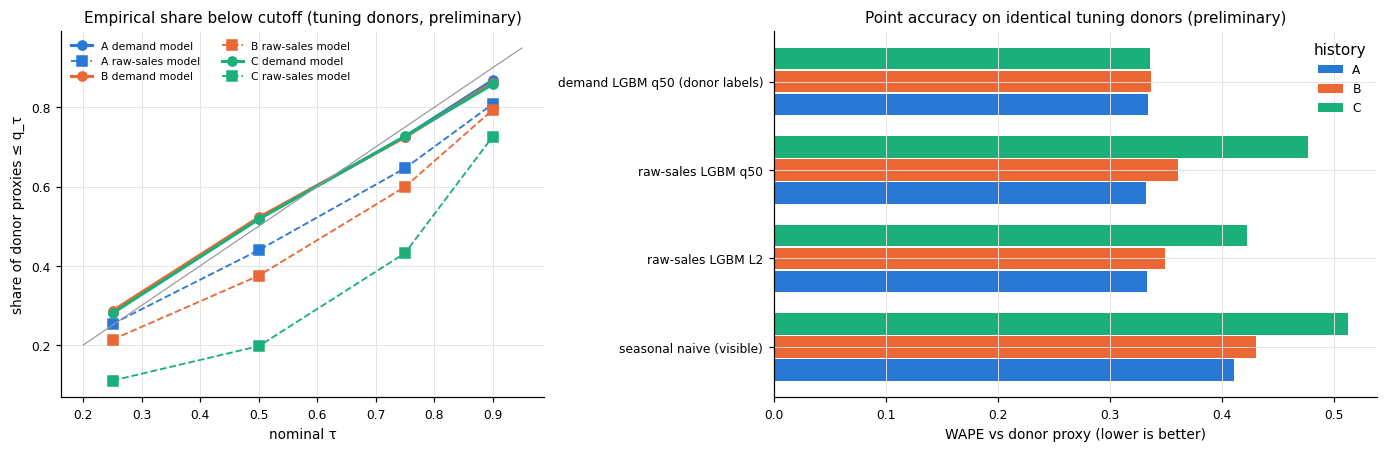

PosixPath('/home/claude/frn/frn_outputs/demo5000/figures/p4_tuning_comparison.png')

In [41]:
CMP, QCMP = [], []
for m in MECHS:
    p3 = pd.read_parquet(OUT / "predictions" / f"phase3_predictions_{m}.parquet")
    j = P4_PRED[m].merge(p3[["sid", "d", "naive", "raw_l2", "raw_q25", "raw_q50", "raw_q75", "raw_q90", "proxy_demand"]], on=["sid", "d"], suffixes=("", "_p3"))
    assert len(j) == len(P4_PRED[m]) and np.allclose(j.proxy_demand, j.proxy_demand_p3)
    for model, col in [("seasonal naive (visible)", "naive"), ("raw-sales LGBM L2", "raw_l2"), ("raw-sales LGBM q50", "raw_q50"), ("demand LGBM q50 (donor labels)", "q50")]:
        CMP.append({"mechanism": m, "model": model, **point_metrics(j.proxy_demand, j[col])})
    for tau, n in zip(TAUS, qn):
        QCMP.append({"mechanism": m, "tau": tau, "raw-sales pinball": pinball(j.proxy_demand.values, j[f"raw_{n}"].values, tau), "demand pinball": pinball(j.proxy_demand.values, j[n].values, tau),
                     "raw share<=q": float((j.proxy_demand <= j[f"raw_{n}"]).mean()), "demand share<=q": float((j.proxy_demand <= j[n]).mean())})
CMP, QCMP = pd.DataFrame(CMP), pd.DataFrame(QCMP)
print("PRELIMINARY - tuning donors only; the tuning dates were also used for early stopping/grid selection")
display(CMP.round(4)); display(QCMP.round(4))
CMP.to_csv(OUT / "metrics" / "phase3_vs_phase4_point_tuning_donors.csv", index=False); QCMP.to_csv(OUT / "metrics" / "phase3_vs_phase4_quantile_tuning_donors.csv", index=False)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw={"width_ratios": [1, 1.25]})
for i, m in enumerate(MECHS):
    q = QCMP[QCMP.mechanism == m]
    axs[0].plot(q.tau, q["demand share<=q"], marker="o", color=COL[m], lw=2, label=f"{m} demand model")
    axs[0].plot(q.tau, q["raw share<=q"], marker="s", color=COL[m], lw=1.2, ls="--", label=f"{m} raw-sales model")
axs[0].plot([0.2, 0.95], [0.2, 0.95], color="#999", lw=0.8); axs[0].set_xlabel("nominal τ"); axs[0].set_ylabel("share of donor proxies ≤ q_τ")
axs[0].set_title("Empirical share below cutoff (tuning donors, preliminary)"); axs[0].legend(ncol=2, fontsize=7)
c = CMP.pivot(index="model", columns="mechanism", values="WAPE").loc[["seasonal naive (visible)", "raw-sales LGBM L2", "raw-sales LGBM q50", "demand LGBM q50 (donor labels)"]]
for i, m in enumerate(MECHS):
    axs[1].barh(np.arange(4) + (i - 1) * 0.26, c[m], height=0.24, color=COL[m], label=m)
axs[1].set_yticks(range(4)); axs[1].set_yticklabels(c.index); axs[1].set_xlabel("WAPE vs donor proxy (lower is better)"); axs[1].legend(title="history")
axs[1].set_title("Point accuracy on identical tuning donors (preliminary)")
savefig(fig, "p4_tuning_comparison.png")

### Exit checks

In [42]:
n_models = sum((OUT / "models" / f"phase4_demand_{n}_{m}.txt").exists() for m in MECHS for n in qn)
gate("Phase 4", "12 demand quantile model files saved", n_models == 12, n_models)
gate("Phase 4", "tuning predictions, chosen settings and donor counts saved", all((OUT / "predictions" / f"phase4_tuning_predictions_{m}.parquet").exists() for m in MECHS) and (OUT / "models" / "phase4_model_info.json").exists())
gate("Phase 4", "training/tuning labels only on real complete donor days (no partly stocked real day labelled)", all(P4_INFO[m]["labels_only_on_real_donors"] for m in MECHS))
gate("Phase 4", "predictions nonnegative and monotone after rearrangement", all((P4_PRED[m][qn].to_numpy() >= 0).all() and (np.diff(P4_PRED[m][qn].to_numpy(), axis=1) >= 0).all() for m in MECHS))
gate("Phase 4", "identical tuning donor IDs across A/B/C and with Phase 3", all(np.array_equal(P4_PRED["A"][["sid", "d"]].values, P4_PRED[m][["sid", "d"]].values) for m in MECHS))
gate("Phase 4", "weights use days <= 60, selection uses days 61-75, no calibration day used", all(P4_INFO[m]["train_max_day"] <= 60 and P4_INFO[m]["tuning_min_day"] >= 61 and P4_INFO[m]["tuning_max_day"] <= 75 for m in MECHS),
     {m: (P4_INFO[m]["train_max_day"], P4_INFO[m]["tuning_min_day"], P4_INFO[m]["tuning_max_day"]) for m in MECHS})
P4_STATUS = gate_summary("Phase 4")

  [PASS] Phase 4 | 12 demand quantile model files saved — 12
  [PASS] Phase 4 | tuning predictions, chosen settings and donor counts saved 
  [PASS] Phase 4 | training/tuning labels only on real complete donor days (no partly stocked real day labelled) 
  [PASS] Phase 4 | predictions nonnegative and monotone after rearrangement 
  [PASS] Phase 4 | identical tuning donor IDs across A/B/C and with Phase 3 
  [PASS] Phase 4 | weights use days <= 60, selection uses days 61-75, no calibration day used — {'A': (60, 61, 75), 'B': (60, 61, 75), 'C': (60, 61, 75)}


,phase,check,status,detail
0,Phase 4,12 demand quantile model files saved,PASS,12
1,Phase 4,"tuning predictions, chosen settings and donor counts saved",PASS,
2,Phase 4,training/tuning labels only on real complete donor days (no partly stocked real day la...,PASS,
3,Phase 4,predictions nonnegative and monotone after rearrangement,PASS,
4,Phase 4,identical tuning donor IDs across A/B/C and with Phase 3,PASS,
5,Phase 4,"weights use days <= 60, selection uses days 61-75, no calibration day used",PASS,"{'A': (60, 61, 75), 'B': (60, 61, 75), 'C': (60, 61, 75)}"


==== Phase 4 EXIT GATE: PASS (6/6 checks passed) ====


# Final summary

Every table below is generated from this execution's objects or from files this notebook wrote. Nothing is typed in by hand.

### 1. Dataset, selection, donor counts and dates

In [43]:
D = pd.read_parquet(OUT / "data" / "daily_table.parquet", columns=["split", "donor"])
summary_counts = pd.DataFrame([
    ("train rows (file)", pf_tr.metadata.num_rows), ("eval rows (file; schema/row count only)", eval_info["rows"]),
    ("series in train", NS_ALL), ("train dates", f"{DATES[0]} .. {DATES[-1]} ({N_DAYS} days)"), ("eval dates", f"{eval_info['dates'][0]} .. {eval_info['dates'][-1]}"),
    ("selected series (this run)", N_SERIES), ("selected series-days", len(D)),
    ("donor days: model_fit (days 1-60)", int(D[D.split == 'model_fit'].donor.sum())), ("donor days: tuning (61-75)", int(D[D.split == 'tuning'].donor.sum())),
    ("donor days: calibration (76-90, counted only)", int(D[D.split == 'calibration'].donor.sum())),
    ("donor share overall", round(D.donor.mean(), 4)), ("Phase 4 train donor rows per mechanism (days 8-60)", P4_INFO["A"]["train_donor_rows"]),
    ("Phase 4 tuning donor rows per mechanism", P4_INFO["A"]["tuning_donor_rows"]),
    ("simulated eligible donor days per mechanism", len(SIMREC["A"])),
    ("masked donor days A / B / C", " / ".join(str(int(SIMREC[m].masked.sum())) for m in MECHS)),
], columns=["quantity", "value"])
display(summary_counts); summary_counts.to_csv(OUT / "metrics" / "final_summary_counts.csv", index=False)

,quantity,value
0,train rows (file),4500000
1,eval rows (file; schema/row count only),350000
2,series in train,50000
3,train dates,2024-03-28 .. 2024-06-25 (90 days)
4,eval dates,2024-06-26 .. 2024-07-02
5,selected series (this run),5000
6,selected series-days,450000
7,donor days: model_fit (days 1-60),163250
8,donor days: tuning (61-75),45097
9,"donor days: calibration (76-90, counted only)",42773


### 2. Real vs simulated observable patterns (A/B/C)

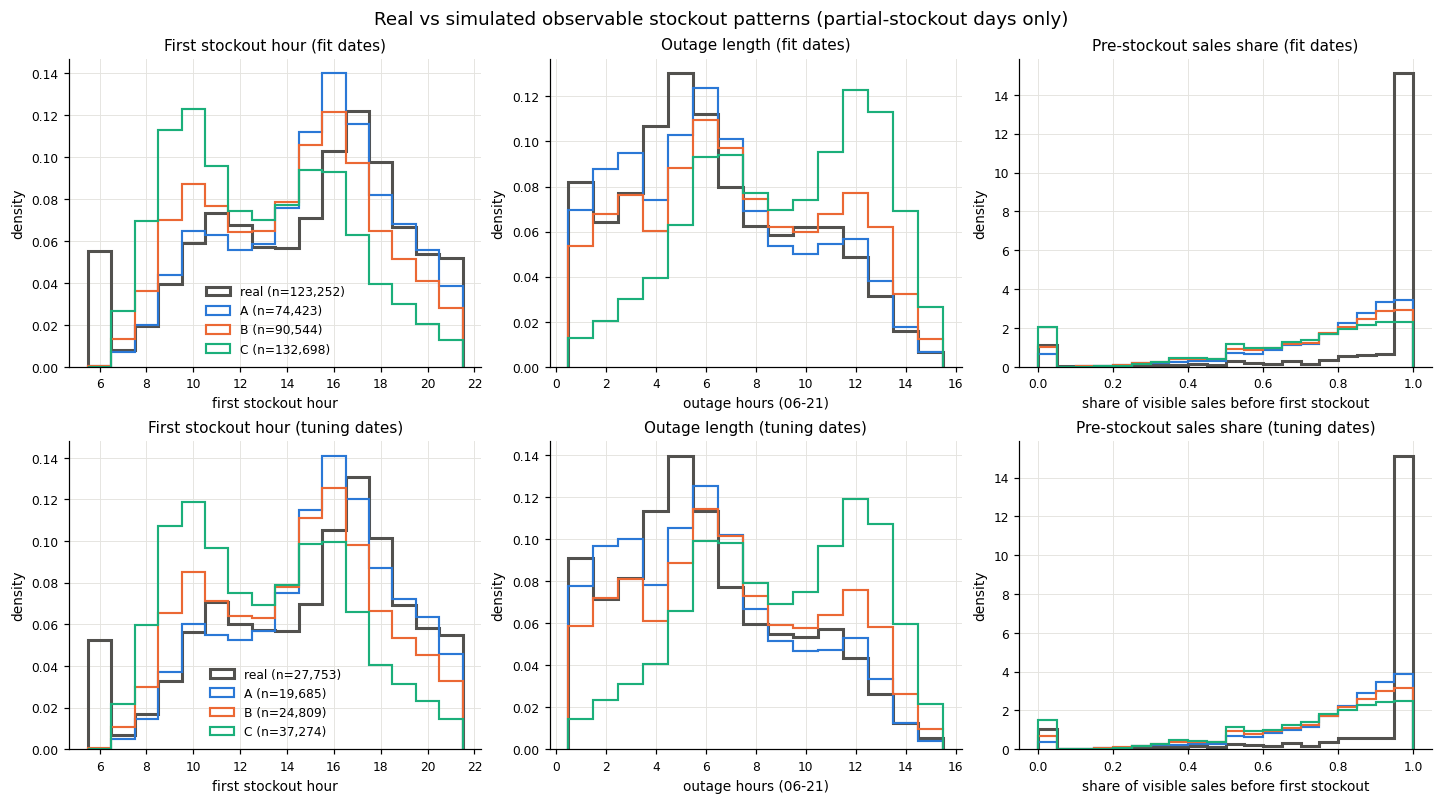

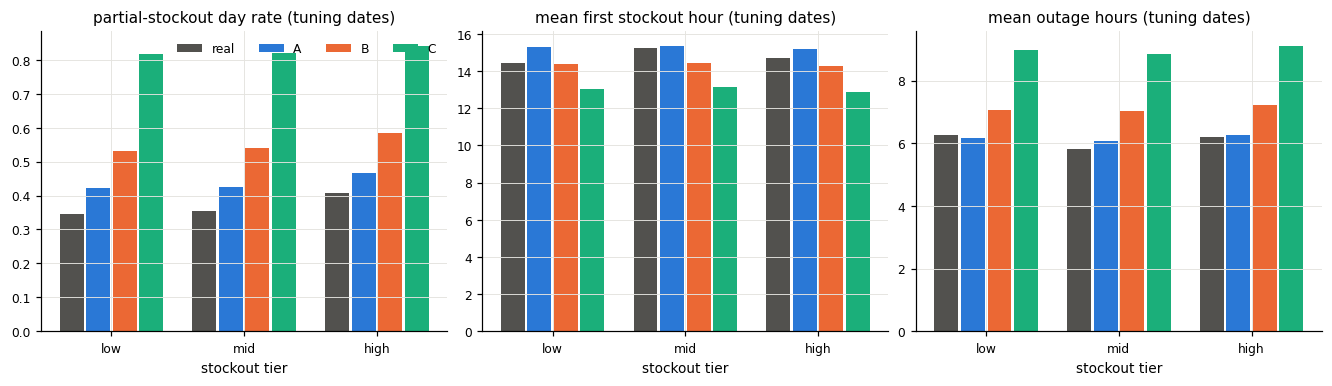

,source,period,rows,partial_stockout_rate,full_outage_rate,mean_first_hour,mean_outage_h,mean_pre_share,recovery_share,loss_vs_real
0,real,fit,300000,0.411,0.045,14.592,6.393,0.887,0.147,0.000
1,real,tuning,75000,0.370,0.029,14.811,6.101,0.888,0.153,0.000
2,A,fit,160869,0.463,0.001,15.006,6.444,0.770,0.130,0.235
3,A,tuning,45097,0.437,0.000,15.298,6.159,0.792,0.130,0.240
4,B,fit,160869,0.563,0.002,14.164,7.296,0.731,0.130,0.414
5,B,tuning,45097,0.550,0.001,14.361,7.095,0.752,0.132,0.436
6,C,fit,160869,0.825,0.006,12.826,9.174,0.675,0.000,0.926
7,C,tuning,45097,0.827,0.004,13.023,8.977,0.700,0.000,0.951


In [44]:
display(IPImage(filename=str(OUT / "figures" / "p2_real_vs_sim_patterns.png")))
display(IPImage(filename=str(OUT / "figures" / "p2_real_vs_sim_by_tier.png")))
display(pat_tbl.round(3))

### 3. A/B/C change historical features while keeping identical target donor IDs

In [45]:
display(FEATDIFF.round(3))

,pair,tuning target donors,y_lag1,y_lag7,y_roll7,y_roll28,y_don_roll14,so_lag1,so_rate14,don_frac7,any timeline feature,identical target donor IDs,identical proxy labels
0,A vs B,45097,0.199,0.177,0.412,0.617,0.360,0.183,0.471,0.280,0.728,True,True
1,A vs C,45097,0.586,0.546,0.978,0.999,0.948,0.569,0.996,0.836,1.000,True,True
2,B vs C,45097,0.585,0.546,0.978,0.999,0.796,0.484,0.989,0.657,1.000,True,True
3,real vs A,45097,0.303,0.294,0.873,0.997,0.973,0.303,0.974,0.873,0.999,True,True
4,real vs B,45097,0.382,0.361,0.910,0.998,0.982,0.383,0.983,0.910,1.000,True,True
5,real vs C,45097,0.586,0.547,0.979,0.999,0.997,0.588,0.997,0.979,1.000,True,True


### 4. Model comparison on tuning donors (PRELIMINARY development diagnostic)
The tuning dates also served for early stopping and grid selection, so these numbers are optimistic. They are not final results.

In [46]:
display(CMP.pivot(index="model", columns="mechanism", values="WAPE").round(4).rename_axis("WAPE vs donor proxy"))
display(CMP.pivot(index="model", columns="mechanism", values="rel_bias").round(4).rename_axis("relative bias vs donor proxy"))
display(QCMP.round(4))

mechanism,A,B,C
WAPE vs donor proxy,,,
demand LGBM q50 (donor labels),0.3334,0.3361,0.3358
raw-sales LGBM L2,0.3330,0.3485,0.4217
raw-sales LGBM q50,0.3315,0.3602,0.4767
seasonal naive (visible),0.4105,0.4305,0.5122


mechanism,A,B,C
relative bias vs donor proxy,,,
demand LGBM q50 (donor labels),-0.0218,-0.0215,-0.0212
raw-sales LGBM L2,-0.0999,-0.1470,-0.3172
raw-sales LGBM q50,-0.1251,-0.1898,-0.4158
seasonal naive (visible),-0.0932,-0.1442,-0.3169


,mechanism,tau,raw-sales pinball,demand pinball,raw share<=q,demand share<=q
0,A,0.25,0.1192,0.1189,0.2531,0.2825
1,A,0.50,0.1594,0.1603,0.4394,0.5189
2,A,0.75,0.1431,0.1358,0.6462,0.7262
3,A,0.90,0.0946,0.0839,0.8084,0.8685
4,B,0.25,0.1255,0.1197,0.2135,0.2862
5,B,0.50,0.1732,0.1616,0.3748,0.5221
6,B,0.75,0.1553,0.1365,0.5992,0.7244
7,B,0.90,0.0991,0.0842,0.7935,0.8627
8,C,0.25,0.1485,0.1206,0.1099,0.2800
9,C,0.50,0.2292,0.1614,0.1969,0.5175


### 5. Runtime and peak memory by stage

In [47]:
STG = pd.DataFrame(STAGES)
display(STG); STG.to_csv(OUT / "metrics" / "runtime_memory.csv", index=False)
print(f"total wall time so far: {time.time() - RUN_T0:.0f} s | machine: {provenance['machine']}")

,stage,seconds,peak_rss_GB,ok
0,P0 provenance + hashes,0.30,0.283,True
1,P0 schema inspection,0.31,0.415,True
2,P0 global streaming audit,9.03,1.073,True
3,P0 series selection,0.50,0.862,True
4,P0 smoke check (10 series),3.42,1.228,True
5,P1 load selected panel,3.72,1.292,True
6,P1 daily table,0.20,0.930,True
7,P1 real-timeline features,0.70,0.998,True
8,P1 leakage perturbation test,3.01,1.089,True
9,P2 simulator fit (fit dates) + tuning check,4.21,0.807,True


total wall time so far: 1195 s | machine: {'platform': 'Linux-6.18.44-fc-v37-x86_64-with-glibc2.39', 'processor': 'x86_64', 'logical_cpus': 2, 'ram_GB': 8.42}


### 6. Limitations (exact)
* **Donor selection.** Donors are days on which stock lasted all day. They under-represent busy and promotion days and high-stockout series (see the donor-selection bias table). Donor proxy labels are therefore a biased sample of demand, and the demand models learn the donor-day demand distribution.
* **The proxy is not true demand.** Even on a donor day, recorded sales equal demand only if the stock flags are accurate. The audit found flagged hours with positive sales, so the hourly flag is an imperfect indicator.
* **Normalised sales.** `hours_sale`/`sale_amount` are normalised values, not unit counts. All errors are on that scale, and no monetary or waste quantity can be derived from them.
* **Unknown real inventory.** Opening stock, orders and refills are not observed. The A/B/C stock rules are hypothetical mechanisms fitted (A) or declared (B, C) to match observable patterns. They are not a model of the retailer's real replenishment.
* **Unknown hidden demand.** For genuinely stocked-out real days, latent demand is unknown. This notebook reports no accuracy on those days and never assigns them a demand label.
* **Future weather and promotion plans are unknown.** Target-day weather, discount and activity values are excluded because their availability time is not documented. The promotion scenario in B is retrospective.
* **Seven-day final horizon.** The final evaluation split covers only 7 days (2024-06-26..07-02). Later conclusions from it will carry large calendar-specific uncertainty. It was not inspected beyond schema and row counts.
* **Tuning reuse.** Days 61–75 were used both to select hyperparameters and simulator adjustments and to report the diagnostics above. The diagnostics are therefore optimistic.

### 7. Output files and truthful phase status

In [48]:
files = sorted(p for p in OUT.rglob("*") if p.is_file())
ftab = pd.DataFrame({"file": [str(p.relative_to(OUT)) for p in files], "bytes": [p.stat().st_size for p in files]})
display(ftab)
ALLG = pd.concat([pd.DataFrame(v) for v in GATES.values()])
phase_status = ALLG.groupby("phase").status.apply(lambda s: "PASS" if (s == "PASS").all() else "FAIL").to_dict()
failed = ALLG[ALLG.status == "FAIL"]
status = {"run_tag": RUN_TAG, "completed_all_cells_utc": dtm.datetime.utcnow().isoformat(timespec="seconds") + "Z",
          "phase_status": phase_status, "failed_checks": failed[["phase", "check", "detail"]].to_dict("records"),
          "n_series": int(N_SERIES), "total_seconds": round(time.time() - RUN_T0, 1), "fast_mode": FAST_MODE}
json.dump(status, open(OUT / "run_status.json", "w"), indent=2)
full_status_path = OUT.parent / "full50k" / "run_status.json"
full_status = json.load(open(full_status_path)) if full_status_path.exists() else None
other_done = True if FULL_RUN else bool(full_status)
run_tbl = pd.DataFrame([
    {"run": RUN_TAG + " (this execution)", "completed": True, "phase gates": phase_status, "seconds": status["total_seconds"]},
    {"run": "full50k (FULL_RUN=True, same notebook)", "completed": other_done,
     "phase gates": phase_status if FULL_RUN else (full_status or {}).get("phase_status", "no completed full-data run found in the output folder"),
     "seconds": status["total_seconds"] if FULL_RUN else (full_status or {}).get("total_seconds")}])
display(run_tbl)
if full_status and not FULL_RUN:
    print("full-data run finished at", full_status["completed_all_cells_utc"], "fast_mode =", full_status.get("fast_mode"))
display(ALLG.reset_index(drop=True))

,file,bytes
0,data/daily_table.parquet,1660789
1,data/features_A.parquet,21088902
2,data/features_B.parquet,21689394
3,data/features_C.parquet,22715221
4,data/features_real.parquet,11068375
5,figures/p1_donors_vs_stockout.png,77537
6,figures/p1_series_histories.png,204178
7,figures/p2_real_vs_sim_by_tier.png,29038
8,figures/p2_real_vs_sim_patterns.png,125511
9,figures/p2_timeline_example.png,91493


,run,completed,phase gates,seconds
0,demo5000 (this execution),True,"{'Phase 0': 'PASS', 'Phase 1': 'PASS', 'Phase 2': 'PASS', 'Phase 3': 'PASS', 'Phase 4'...",1194.9
1,"full50k (FULL_RUN=True, same notebook)",True,"{'Phase 0': 'PASS', 'Phase 1': 'PASS', 'Phase 2': 'PASS', 'Phase 3': 'PASS', 'Phase 4'...",4210.4


full-data run finished at 2026-09-20T16:02:25Z fast_mode = True


,phase,check,status,detail
0,Phase 0,schema has all expected fields (train & eval),PASS,
1,Phase 0,"train rows == 4,500,000",PASS,4500000
2,Phase 0,"eval rows == 350,000",PASS,350000
3,Phase 0,eval dates are 2024-06-26..2024-07-02,PASS,
4,Phase 0,static category IDs constant within each series,PASS,
5,Phase 0,"50,000 series x 90 dates, no duplicate or missing keys",PASS,"series=50000, dup=0, missing=0"
6,Phase 0,series selection deterministic within session,PASS,
7,Phase 0,selected series count == 5000,PASS,5000
8,Phase 0,tier composition of sample within 1 pp of population,PASS,
9,Phase 0,"hand example [2,3,4,1] with stock 6 -> [2,3,1,0], total 6, proxy 10",PASS,


### 8. Next phases (not performed in this notebook)
Kaplan–Meier / censored-demand estimation for ordering, TimesNet/TFT deep models, conformal calibration on the reserved days 76–90, the inventory ordering simulation and cost optimisation, and the final A→B/C transfer evaluation on the untouched 2024-06-26..07-02 week have **not** been performed here. Nothing in this notebook is a final benchmark, a coverage guarantee, a waste or profit saving, or an accuracy claim on genuinely stocked-out days.